# PA1 Task 4 - Open-set recognition on Kaggle

**What happens.** Three CIFAR-10 classifiers are trained, their outputs are frozen, and only then are the
CIFAR-100 unknowns loaded and evaluated.

| Part | What happens | Data touched | Time (T4) |
|---|---|---|---|
| A | GPU check, working copy, CIFAR-10 download, 45k/5k split, **smoke test** of the whole known-side pipeline | CIFAR-10 | ~5 min |
| B | **Vanilla**: CIFAR ResNet-18, cross-entropy, 100 epochs | CIFAR-10 train / val | ~45 min |
| C | **GCSC**: the same recipe + RandAugment(2, 9), 100 epochs | CIFAR-10 train / val | ~60 min |
| D | **PROSER**: Vanilla + 5 dummy classifiers, 50 epochs of fine-tuning | CIFAR-10 train / val | ~25 min |
| E | Save features/logits for CIFAR-10, compute every threshold, write the **freeze record** | CIFAR-10 train / val / test | ~3 min |
| F | **First CIFAR-100 access**: unknown outputs, Tables 1 and 2, statistics, figures | + CIFAR-100 test (16 classes) | ~5 min |
| G | Failure analysis under the Vanilla-MLS threshold | same | ~1 min |
| I | **POST-HOC**: PROSER BatchNorm diagnosis + recalibrated variant (separate freeze, separate tables) | CIFAR-10, then CIFAR-100 test | ~20 min |
| H | Package the results for GitHub | - | - |

Parts E and F also compare this run with **run 1** (the first, interactive run, whose files were lost; its key
numbers ship in `task4/run1/`). Same code and seed, so the checkpoints should match run 1's hashes.

**Why this order.** The handout says CIFAR-100 may not influence training, checkpoint selection, score design or
thresholds, and unknowns may be evaluated only after every checkpoint and score definition is fixed.
- Parts A to E never download CIFAR-100.
- Part E writes `frozen.json`. It holds the SHA-256 of every checkpoint and of every file that defines a score or
  threshold, plus the Mahalanobis statistics and the thresholds.
- The code refuses to load CIFAR-100 unless all of those still match. Every access is timestamped in
  `unknown_access_log.json`.

**Datasets to attach.**
1. `pa1-task4.zip` (required), uploaded as a Kaggle dataset under any name; Part A1 finds it by what is inside it.
2. **Recommended:** a Kaggle copy of CIFAR-10 and of CIFAR-100 in the original Python format (folders
   `cifar-10-batches-py` and `cifar-100-python`). In run 1 the two downloads took about 40 GPU-minutes.
   - An attached copy is used only if every file matches torchvision's official MD5 checksums; otherwise the
     notebook downloads the original.
   - Attaching CIFAR-100 does not break the freeze order: nothing reads it before Part F.

**Settings (right panel).**
- Accelerator = **GPU T4 x2**. Avoid the P100: current PyTorch builds may not support it, and A0 checks for this.
- Internet = **ON**.
- Then **Save Version -> Save & Run All (Commit)** and close the tab. The whole notebook runs in the background
  (about 2 h with the CIFAR copies attached, 2.5-3 h without; the limit is 12 h).
- **Do not use the editor's Run All for the real run.** An interactive session's files vanish when it ends,
  which is how run 1's outputs were lost. A committed version keeps its Output tab permanently.

**Outputs** (Output tab of the saved version):
- `outputs/task4_outputs.zip`: everything to commit. Extract it at the repository root.
- `outputs/task4_checkpoints.zip`: the three selected checkpoints. Keep them, but do not commit them.
- `outputs/task4_cache.zip` (~0.4 GB): the saved features and logits the frozen thresholds come from. Keep it
  if you may want to re-run the evaluation later. Do not commit it.

The zips are rebuilt after every Part, so a failure late in the run does not lose the earlier Parts.

**If the run crashes after training** (e.g. in Part F):
1. Attach the crashed version's Output as an input (Add Input -> Your Work).
2. Set `RESUME = True` in cell A1 and run again.
3. Finished models are not retrained, and the saved outputs and freeze record are reused.

This costs minutes instead of hours.

## Part A - setup

In [1]:
# A0. Hard GPU check, before anything else. The P100 (compute capability 6.0) is no longer supported by
# recent PyTorch builds: the check runs a real convolution so an unsupported GPU fails HERE, not an hour in.
import os, sys, glob, json, shutil, time, subprocess, platform
import torch, torchvision
T_START = time.time()
if not torch.cuda.is_available():
    raise RuntimeError('NO GPU. Settings (right panel) -> Accelerator -> GPU T4 x2, then Run All again.')
name = torch.cuda.get_device_name(0)
try:
    x = torch.randn(8, 3, 32, 32, device='cuda')
    y = torch.nn.Conv2d(3, 8, 3, padding=1).cuda()(x).sum().item()
    with torch.autocast('cuda', dtype=torch.float16):
        torch.nn.Conv2d(3, 8, 3, padding=1).cuda()(x).sum().item()
except Exception as e:
    raise RuntimeError(f'The GPU ({name}) cannot run PyTorch {torch.__version__} kernels: {e}\n'
                       'Switch the accelerator to GPU T4 x2 and Run All again.') from e
ENV = {'gpu': name, 'gpu_count': torch.cuda.device_count(), 'torch': torch.__version__,
       'torchvision': torchvision.__version__, 'cuda': torch.version.cuda, 'cudnn': torch.backends.cudnn.version(),
       'python': platform.python_version(), 'cpus': os.cpu_count()}
for k, v in ENV.items():
    print(f'  {k:12s} {v}')
print('\nGPU OK. Only GPU 0 is used, so the run is the same on "T4 x2" and on a single T4.')

  gpu          Tesla T4
  gpu_count    2
  torch        2.10.0+cu128
  torchvision  0.25.0+cu128
  cuda         12.8
  cudnn        91002
  python       3.12.13
  cpus         4

GPU OK. Only GPU 0 is used, so the run is the same on "T4 x2" and on a single T4.


In [2]:
# A1. Assemble a FRESH working copy from the attached code dataset. /kaggle/input is read-only, so everything
# runs in /kaggle/working/PA1. The dataset is found by its content, so its name and nesting do not matter.
RESUME = False   # leave False. Set True ONLY to recover a crashed run: attach that saved version's Output as an
                 # input (Add Input -> Your Work -> the notebook). Training, the freeze and the cache are restored.
REPO  = '/kaggle/working/PA1'
OUT   = '/kaggle/working/outputs'           # the zips you download at the end
DATA  = '/tmp/cifar'                        # datasets (outside /kaggle/working: not saved as output)
CACHE = '/tmp/task4_cache'                  # saved features/logits (~0.5 GB, rebuilt by Part E if needed)

def roots_with(marker):
    hits = glob.glob(f'/kaggle/input/**/{marker}', recursive=True)
    return sorted({h[: -len(marker) - 1] for h in hits})

code_roots = [r for r in roots_with('task4/train.py') if os.path.exists(f'{r}/task4/freeze.py')
              and os.path.exists(f'{r}/common/io.py')]
assert code_roots, ('No attached dataset contains task4/train.py + task4/freeze.py + common/io.py. Upload '
                    'pa1-task4.zip as a Kaggle dataset and attach it (right panel -> Add Input).')
if len(code_roots) > 1:
    print(f'WARNING: {len(code_roots)} copies of the Task 4 code are attached; using the first: {code_roots}')
os.makedirs(REPO, exist_ok=True); os.makedirs(OUT, exist_ok=True)
shutil.copytree(code_roots[0], REPO, dirs_exist_ok=True, ignore=shutil.ignore_patterns('results', 'cache', '.git'))
os.chdir(REPO)
sys.path.insert(0, REPO)

# First run of A1 in this session: guarantee that no results exist, so nothing from an earlier session can
# leak in. Re-running A1 later in the SAME session keeps what has been trained since.
MARKER = f'{REPO}/.task4_fresh_session'
if not os.path.exists(MARKER):
    for d in ['task4/results', 'task4/cache', CACHE, '/tmp/t4smoke']:
        if os.path.isdir(d):
            shutil.rmtree(d); print(f'  deleted old {d}/')
    open(MARKER, 'w').write(time.ctime())
    print('  fresh session: no earlier Task 4 results exist in the working copy')
else:
    print('  A1 re-run inside the same session: keeping the runs trained since the session started')

# Crash recovery (only if RESUME = True): restore the outputs of an earlier saved version of THIS notebook.
import zipfile
prev = sorted(glob.glob('/kaggle/input/**/task4_checkpoints.zip', recursive=True))
if prev and not RESUME:
    print(f'  NOTE: outputs of an earlier run are attached ({os.path.dirname(prev[0])}) but RESUME = False: ignored.')
if RESUME:
    assert prev, 'RESUME = True but no earlier task4_checkpoints.zip is attached.'
    src = os.path.dirname(prev[0])
    for z, dest in [('task4_outputs.zip', REPO), ('task4_checkpoints.zip', REPO), ('task4_cache.zip', CACHE)]:
        if os.path.exists(f'{src}/{z}'):
            zipfile.ZipFile(f'{src}/{z}').extractall(dest)
            print(f'  RESUMED: {z} -> {dest}')
    print('  Finished runs will be skipped, saved outputs kept (--skip-existing) and the freeze record verified.')

import task4
print(f'\n  code     : {code_roots[0]}  ->  {REPO}')
print(f'  version  : {task4.CODE_VERSION}')
print(f'  contents : {sorted(os.listdir(REPO))}')
print(f'  task4/   : {sorted(os.listdir("task4"))}')

  fresh session: no earlier Task 4 results exist in the working copy

  code     : /kaggle/input/datasets/zylah628/pa1-task4  ->  /kaggle/working/PA1
  version  : task4-v1 (2026-09-20)
  contents : ['.task4_fresh_session', 'common', 'notebooks', 'task4']
  task4/   : ['README.md', '__init__.py', '__pycache__', 'audit.py', 'configs', 'data', 'evaluate_osr.py', 'evaluation', 'extract_outputs.py', 'freeze.py', 'methods', 'models', 'posthoc', 'run1', 'scores', 'train.py']


In [3]:
# A2. CIFAR-10 only. CIFAR-100 is NOT downloaded here: it is first needed in Part F, after the freeze.
from torchvision import datasets
from torchvision.datasets.utils import check_integrity

def attach_if_valid(cls):
    '''Use an attached Kaggle copy of the dataset ONLY if every file matches torchvision's official MD5 checksums
    (checksums are computed on the files; nothing is decoded). Otherwise torchvision downloads the original.
    Attaching the copies saves ~40 GPU-minutes: in run 1 the two downloads took most of Parts A and F.'''
    folder, target = cls.base_folder, f'{DATA}/{cls.base_folder}'
    if os.path.exists(target):
        return
    files = cls.train_list + cls.test_list + [[cls.meta['filename'], cls.meta['md5']]]
    for p in glob.glob(f'/kaggle/input/**/{folder}', recursive=True):
        if os.path.isdir(p):
            ok = all(check_integrity(os.path.join(p, f), md5) for f, md5 in files)
            print(f'{folder}: attached copy {p} -> MD5 {"match, using it" if ok else "MISMATCH, ignored"}')
            if ok:
                os.symlink(p, target)
                return
    print(f'{folder}: no valid attached copy - downloading from the official source')

os.makedirs(DATA, exist_ok=True)
attach_if_valid(datasets.CIFAR10)
target = f'{DATA}/cifar-10-batches-py'
try:
    tr = datasets.CIFAR10(DATA, train=True, download=not os.path.exists(target))
    te = datasets.CIFAR10(DATA, train=False, download=False)
except Exception as e:
    raise RuntimeError('CIFAR-10 could not be downloaded or verified. Either turn Internet ON, or attach the '
                       'Kaggle dataset "CIFAR-10 Python" (it contains cifar-10-batches-py).') from e
import numpy as np
print(f'CIFAR-10 in {DATA}: official train {len(tr)} images, test {len(te)} images (MD5 checked by torchvision)')
print('  classes      :', tr.classes)
print('  train/class  :', np.bincount(tr.targets).tolist())
print('  test/class   :', np.bincount(te.targets).tolist())
assert len(tr) == 50000 and len(te) == 10000
assert not os.path.exists(f'{DATA}/cifar-100-python'), 'CIFAR-100 must not be present before the freeze'

cifar-10-batches-py: attached copy /kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py -> MD5 match, using it
CIFAR-10 in /tmp/cifar: official train 50000 images, test 10000 images (MD5 checked by torchvision)
  classes      : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
  train/class  : [5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000]
  test/class   : [1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000]


In [4]:
# A3. The stratified 90/10 split of the official training partition (seed 6304): 4,500 + 500 per class.
# If the split file already exists (e.g. committed from an earlier run), the script re-derives it and stops if
# it differs; otherwise it writes it. The file goes into the output zip, so you can commit it.
def run(cmd, env_extra=None):
    '''Run a shell command from the repo root, stream its output, stop the notebook if it fails.'''
    print('$', cmd, flush=True)
    t0 = time.time()
    env = dict(os.environ, **(env_extra or {}))
    p = subprocess.Popen(cmd, shell=True, cwd=REPO, env=env, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                         text=True, bufsize=1)
    for line in p.stdout:
        print(line, end='')
    if p.wait() != 0:
        raise RuntimeError(f'Command failed (exit code {p.returncode}): {cmd}')
    print(f'  [{(time.time() - t0) / 60:.1f} min]', flush=True)

run(f'python -m task4.data.make_splits --data_root {DATA}')
run(f'python -m task4.data.make_splits --data_root {DATA} --verify')
split = json.load(open('task4/data/splits/cifar10_split_seed6304.json'))
assert split['n_train'] == 45000 and split['n_val'] == 5000 and not set(split['train']) & set(split['val'])
print(f"\nsplit OK: {split['n_train']} train / {split['n_val']} val, sha256 {split['sha256'][:16]}...")

$ python -m task4.data.make_splits --data_root /tmp/cifar
official training partition: 50000 images
  train 45000   val 5000
  class         train   val
  airplane       4500   500
  automobile     4500   500
  bird           4500   500
  cat            4500   500
  deer           4500   500
  dog            4500   500
  frog           4500   500
  horse          4500   500
  ship           4500   500
  truck          4500   500

wrote /kaggle/working/PA1/task4/data/splits/cifar10_split_seed6304.json  (sha256 456aac6ee532f72c...)
  [0.1 min]
$ python -m task4.data.make_splits --data_root /tmp/cifar --verify
official training partition: 50000 images
  train 45000   val 5000
  class         train   val
  airplane       4500   500
  automobile     4500   500
  bird           4500   500
  cat            4500   500
  deer           4500   500
  dog            4500   500
  frog           4500   500
  horse          4500   500
  ship           4500   500
  truck          4500   500

verify: t

In [5]:
# A4. Helpers used below.
#   COMMON              the overrides every command gets (data and cache locations)
#   show_config(name)   the resolved config next to what the handout requires
#   show_history(run)   training curves
#   save_outputs(tag)   rebuild the two output zips (called after every Part)
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
from common.io import load_config
pd.set_option('display.width', 220); pd.set_option('display.max_columns', 40); pd.set_option('display.max_colwidth', 80)

COMMON = f'data_root={DATA} cache_dir={CACHE}'
RUNS_DIR, FROZEN_DIR, FINAL_DIR = 'task4/results/runs', 'task4/results/frozen', 'task4/results/final'
os.makedirs('task4/results', exist_ok=True)
json.dump(ENV, open('task4/results/environment.json', 'w'), indent=2)
TIMES = {}

# What the handout fixes for each model (Dataset/Models/Setup section and Steps 3-4).
SHARED = {'seed': 6304, 'batch_size': 128, 'momentum': 0.9, 'weight_decay': 5e-4, 'scheduler': 'cosine', 'val_fraction': 0.1}
HANDOUT = {'vanilla': {**SHARED, 'epochs': 100, 'lr': 0.1},
           'gcsc': {**SHARED, 'epochs': 100, 'lr': 0.1, 'method.randaugment_num_ops': 2, 'method.randaugment_magnitude': 9},
           'proser': {**SHARED, 'epochs': 50, 'lr': 0.001, 'method.n_dummies': 5, 'method.beta': 1.0, 'method.gamma': 0.1,
                      'method.mixup_alpha': 2.0, 'method.mix_after': 'layer2'}}
def show_config(name):
    cfg = load_config(f'task4/configs/{name}.yaml')
    flat = {k: v for k, v in cfg.items() if k != 'method'}
    flat.update({f'method.{k}': v for k, v in cfg['method'].items()})
    req = HANDOUT[name]
    rows = [{'setting': k, 'config': v, 'handout': req.get(k, ''), 'match': ('yes' if req[k] == v else 'NO') if k in req else ''}
            for k, v in flat.items()]
    display(pd.DataFrame(rows))
    bad = [r['setting'] for r in rows if r['match'] == 'NO']
    assert not bad, f'{name}: config differs from the handout for {bad}'
    print(f'{name}: every setting the handout fixes matches ({len(req)} checked). data_root / cache_dir are '
          'overridden at run time with the Kaggle paths.')
    return cfg

def show_history(run, title=None, runs_dir=None):
    runs_dir = runs_dir or RUNS_DIR
    h = pd.DataFrame(json.load(open(f'{runs_dir}/{run}/history.json')))
    s = json.load(open(f'{runs_dir}/{run}/summary.json'))
    extra = 'cp_ce' in h
    fig, ax = plt.subplots(1, 3 if extra else 2, figsize=(16 if extra else 11, 3.6))
    ax[0].plot(h.epoch, h.loss, label='total loss')
    if extra:
        for k, lab in [('cp_ce', 'CE (known)'), ('cp_dummy', 'masked CE -> dummy'), ('dp', 'mixup CE -> dummy')]:
            ax[0].plot(h.epoch, h[k], label=lab)
    ax[0].set_xlabel('epoch'); ax[0].set_title('training loss'); ax[0].legend(fontsize=8)
    ax[1].plot(h.epoch, h.train_acc, label='train (augmented)'); ax[1].plot(h.epoch, h.val_acc, label='val')
    ax[1].axvline(s['best_epoch'], ls='--', c='k', lw=0.8, label=f"selected: epoch {s['best_epoch']}")
    ax[1].set_xlabel('epoch'); ax[1].set_ylabel('%'); ax[1].set_title('accuracy'); ax[1].legend(fontsize=8)
    if extra:
        ax[2].plot(h.epoch, h.val_dummy_wins); ax[2].set_xlabel('epoch')
        ax[2].set_title('% of known VAL images whose max dummy beats every known logit')
    fig.suptitle(title or run); fig.tight_layout(); plt.show()
    print(f"{run}: best val acc {s['best_val_acc']:.2f}% at epoch {s['best_epoch']} / {s['epochs']}, last epoch "
          f"{s['last_val_acc']:.2f}%, {s['train_minutes']:.1f} min on {s['device']}")
    return h, s

def save_outputs(tag):
    '''task4_outputs.zip = everything to commit (no checkpoints); task4_checkpoints.zip = the best.pt files;
    task4_cache.zip = the saved features/logits the frozen thresholds were computed from (needed to re-run the
    evaluation later without re-extracting, which on other hardware would not reproduce them bit for bit).'''
    import zipfile
    light, heavy, cache_zip = f'{OUT}/task4_outputs.zip', f'{OUT}/task4_checkpoints.zip', f'{OUT}/task4_cache.zip'
    n_light = n_heavy = 0
    with zipfile.ZipFile(light, 'w', zipfile.ZIP_DEFLATED) as zl, zipfile.ZipFile(heavy, 'w') as zh:
        for base in ['task4/results', 'task4/data/splits']:
            for root, _, files in os.walk(base):
                for f in files:
                    p = os.path.join(root, f)
                    if f.endswith(('.pt', '.pth')):
                        zh.write(p); n_heavy += 1
                    else:
                        zl.write(p); n_light += 1
    mb = lambda p: os.path.getsize(p) / 2**20
    print(f'[{tag}] saved {light} ({n_light} files, {mb(light):.1f} MB) and {heavy} ({n_heavy} checkpoints, '
          f'{mb(heavy):.0f} MB)')
    if os.path.isdir(CACHE) and any(f.endswith('.npz') for _, _, fs in os.walk(CACHE) for f in fs):
        with zipfile.ZipFile(cache_zip, 'w', zipfile.ZIP_STORED) as zc:
            for root, _, files in os.walk(CACHE):
                for f in files:
                    zc.write(os.path.join(root, f), os.path.relpath(os.path.join(root, f), CACHE))
        print(f'[{tag}] saved {cache_zip} ({mb(cache_zip):.0f} MB of features/logits)')

save_outputs('A')

[A] saved /kaggle/working/outputs/task4_outputs.zip (2 files, 0.1 MB) and /kaggle/working/outputs/task4_checkpoints.zip (0 checkpoints, 0 MB)


In [6]:
# A5. SMOKE TEST (about 2 minutes): the whole CIFAR-10 side of the pipeline on tiny data before spending hours.
# Each model trains 1 epoch on 1,024 images, then outputs are extracted and a throw-away freeze is written - all in
# /tmp/t4smoke, which is deleted afterwards. The smoke test does NOT touch CIFAR-100 (that would come before the
# real freeze). Nothing from it is used later.
SMOKE = '/tmp/t4smoke'
SM = (f'{COMMON} results_dir={SMOKE}/runs cache_dir={SMOKE}/cache frozen_file={SMOKE}/frozen/frozen.json '
      f'debug_subset=1024 epochs=1')
t0 = time.time()
run(f'python -m task4.train --config task4/configs/vanilla.yaml --set {SM}')
run(f'python -m task4.train --config task4/configs/gcsc.yaml --set {SM}')
run(f'python -m task4.train --config task4/configs/proser.yaml --set {SM} init_from={SMOKE}/runs/vanilla/best.pt')
run(f'python -m task4.extract_outputs --stage known --set {SM}')
run(f'python -m task4.freeze --set {SM}')
# the post-hoc CIFAR-10-only code paths (Part I): BatchNorm diagnosis and the recalibrated PROSER variant
run(f'python -m task4.posthoc.bn_diagnosis --set {SM} posthoc_dir={SMOKE}/posthoc --recal_batches 2')
run(f'python -m task4.train --config task4/configs/proser_bncal.yaml --set {SM} results_dir={SMOKE}/posthoc_runs '
    f'init_from={SMOKE}/runs/vanilla/best.pt bn_recalibrate_batches=2')
shutil.rmtree(SMOKE)
print(f'\nSMOKE TEST PASSED in {(time.time() - t0) / 60:.1f} min - starting the real runs.')

$ python -m task4.train --config task4/configs/vanilla.yaml --set data_root=/tmp/cifar cache_dir=/tmp/task4_cache results_dir=/tmp/t4smoke/runs cache_dir=/tmp/t4smoke/cache frozen_file=/tmp/t4smoke/frozen/frozen.json debug_subset=1024 epochs=1
=== vanilla ===
  method        : cross-entropy on the 10 CIFAR-10 classes; augmentation = random crop (pad 4) + horizontal flip
  device        : Tesla T4 | AMP True | channels_last True | cuDNN deterministic True
  data          : train 1024 images (classes [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), val 1024 images   [DEBUG SUBSET 1024]
  optimisation  : SGD lr 0.1 momentum 0.9 wd 0.0005, cosine over 1 epochs, batch 128, 8 steps/epoch, seed 6304
  parameters    : 11.17 M
  checkpoint    : highest CIFAR-10 validation accuracy -> /tmp/t4smoke/runs/vanilla/best.pt

ep   1/1 | lr 0.10000 | loss 3.2416 | train  12.89% | val   9.86% * (best 9.86 @ 1) | 2s | ETA 0 min

finished vanilla in 0.0 min: best val acc 9.86% at epoch 1 (last epoch 9.86%)
  [0.1 min]
$ p

## Part B - Vanilla closed-set baseline

The ten-class CIFAR ResNet-18 is trained with cross-entropy from random initialisation.
- Architecture: a 3x3 stride-1 first convolution and no initial max-pool, on the original 32x32 images.
- Recipe: random crop (padding 4) + horizontal flip; SGD lr 0.1, momentum 0.9, weight decay 5e-4, cosine decay;
  batch 128; 100 epochs; seed 6304.
- The checkpoint kept is the epoch with the highest accuracy on the 5,000 validation images.
- The CIFAR-10 test set is **not** looked at during training.

Mixed precision (AMP) and deterministic cuDNN are on. AMP only speeds the matrix maths up; validation and every
later evaluation run in float32.

,setting,config,handout,match
0,seed,6304,6304,yes
1,data_root,data,,
2,split_file,task4/data/splits/cifar10_split_seed6304.json,,
3,val_fraction,0.1,0.1,yes
4,batch_size,128,128,yes
5,epochs,100,100,yes
6,lr,0.1,0.1,yes
7,momentum,0.9,0.9,yes
8,weight_decay,0.0005,0.0005,yes
9,scheduler,cosine,cosine,yes


vanilla: every setting the handout fixes matches (8 checked). data_root / cache_dir are overridden at run time with the Kaggle paths.
$ python -m task4.train --config task4/configs/vanilla.yaml --set data_root=/tmp/cifar cache_dir=/tmp/task4_cache
=== vanilla ===
  method        : cross-entropy on the 10 CIFAR-10 classes; augmentation = random crop (pad 4) + horizontal flip
  device        : Tesla T4 | AMP True | channels_last True | cuDNN deterministic True
  data          : train 45000 images (classes [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), val 5000 images
  optimisation  : SGD lr 0.1 momentum 0.9 wd 0.0005, cosine over 100 epochs, batch 128, 352 steps/epoch, seed 6304
  parameters    : 11.17 M
  checkpoint    : highest CIFAR-10 validation accuracy -> /kaggle/working/PA1/task4/results/runs/vanilla/best.pt

ep   1/100 | lr 0.10000 | loss 1.9605 | train  29.55% | val  41.84% * (best 41.84 @ 1) | 16s | ETA 26 min
ep   2/100 | lr 0.09998 | loss 1.4595 | train  46.56% | val  53.84% * (best 53.84

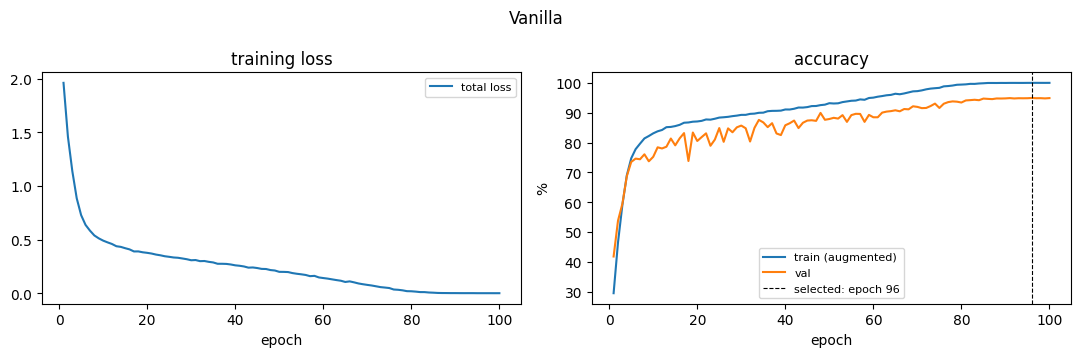

vanilla: best val acc 94.92% at epoch 96 / 100, last epoch 94.88%, 25.7 min on Tesla T4
[B] saved /kaggle/working/outputs/task4_outputs.zip (5 files, 0.1 MB) and /kaggle/working/outputs/task4_checkpoints.zip (2 checkpoints, 85 MB)


In [7]:
t0 = time.time()
cfg = show_config('vanilla')
run(f'python -m task4.train --config task4/configs/vanilla.yaml --set {COMMON}')
TIMES['B vanilla'] = (time.time() - t0) / 60
h_v, s_v = show_history('vanilla', 'Vanilla')
save_outputs('B')

## Part C - GCSC: the same recipe + RandAugment(num_ops=2, magnitude=9)

The handout calls for exactly one change: RandAugment is inserted after the crop and flip, before ToTensor/Normalize.
The table below lists every config key that differs from Vanilla. It should show only the run name and the
RandAugment settings.

The seed is the same, so GCSC starts from the **same initial weights** as Vanilla.

,setting,config,handout,match
0,seed,6304,6304,yes
1,data_root,data,,
2,split_file,task4/data/splits/cifar10_split_seed6304.json,,
3,val_fraction,0.1,0.1,yes
4,batch_size,128,128,yes
5,epochs,100,100,yes
6,lr,0.1,0.1,yes
7,momentum,0.9,0.9,yes
8,weight_decay,0.0005,0.0005,yes
9,scheduler,cosine,cosine,yes


gcsc: every setting the handout fixes matches (10 checked). data_root / cache_dir are overridden at run time with the Kaggle paths.


,setting,vanilla,gcsc
0,method.name,vanilla,gcsc
1,method.randaugment_magnitude,-,9
2,method.randaugment_num_ops,-,2
3,run_name,vanilla,gcsc


GCSC training transform: Compose(
    RandomCrop(size=(32, 32), padding=4)
    RandomHorizontalFlip(p=0.5)
    RandAugment(num_ops=2, magnitude=9, num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
    ToTensor()
    Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.247, 0.2435, 0.2616))
)
$ python -m task4.train --config task4/configs/gcsc.yaml --set data_root=/tmp/cifar cache_dir=/tmp/task4_cache
=== gcsc ===
  method        : Vanilla + RandAugment(num_ops=2, magnitude=9) after crop/flip, before ToTensor/Normalize
  device        : Tesla T4 | AMP True | channels_last True | cuDNN deterministic True
  data          : train 45000 images (classes [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), val 5000 images
  optimisation  : SGD lr 0.1 momentum 0.9 wd 0.0005, cosine over 100 epochs, batch 128, 352 steps/epoch, seed 6304
  parameters    : 11.17 M
  checkpoint    : highest CIFAR-10 validation accuracy -> /kaggle/working/PA1/task4/results/runs/gcsc/best.pt

ep   1/100 | lr 0.10000

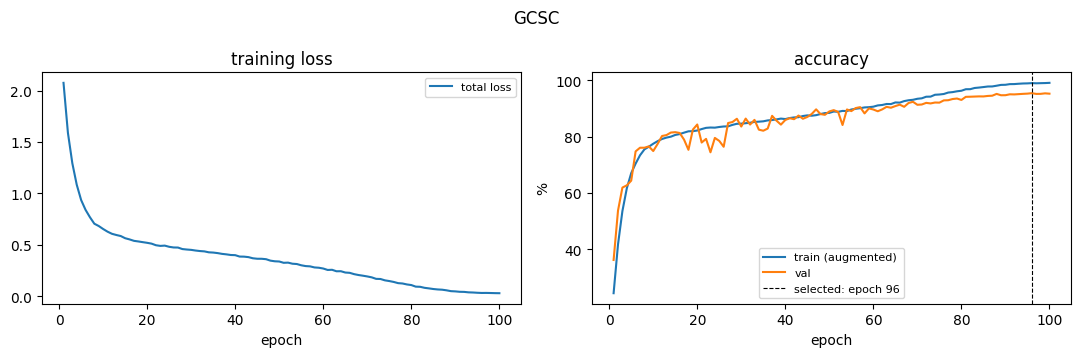

gcsc: best val acc 95.40% at epoch 96 / 100, last epoch 95.22%, 29.5 min on Tesla T4


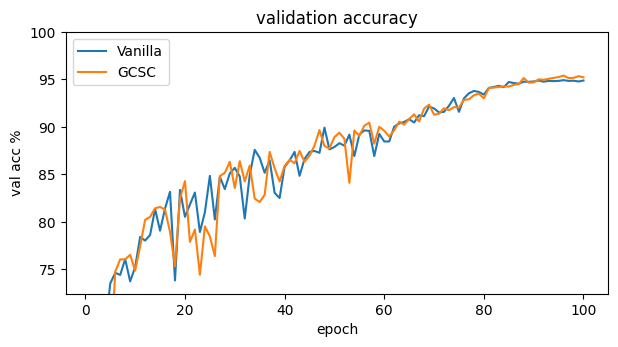

selected checkpoints: Vanilla 94.92% (epoch 96), GCSC 95.40% (epoch 96)  [validation; test CSA comes in Part F]
[C] saved /kaggle/working/outputs/task4_outputs.zip (8 files, 0.1 MB) and /kaggle/working/outputs/task4_checkpoints.zip (4 checkpoints, 171 MB)


In [8]:
t0 = time.time()
show_config('gcsc')
cv, cg = load_config('task4/configs/vanilla.yaml'), load_config('task4/configs/gcsc.yaml')
flat = lambda c: {**{k: v for k, v in c.items() if k != 'method'}, **{f'method.{k}': v for k, v in c['method'].items()}}
fv, fg = flat(cv), flat(cg)
diff = [{'setting': k, 'vanilla': fv.get(k, '-'), 'gcsc': fg.get(k, '-')} for k in sorted(set(fv) | set(fg))
        if fv.get(k) != fg.get(k)]
display(pd.DataFrame(diff))
from task4.data.cifar10 import build_transform
print('GCSC training transform:', build_transform('gcsc'))
run(f'python -m task4.train --config task4/configs/gcsc.yaml --set {COMMON}')
TIMES['C gcsc'] = (time.time() - t0) / 60
h_g, s_g = show_history('gcsc', 'GCSC')
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(h_v.epoch, h_v.val_acc, label='Vanilla'); ax.plot(h_g.epoch, h_g.val_acc, label='GCSC')
ax.set_ylim(max(0, min(h_v.val_acc.iloc[20:].min(), h_g.val_acc.iloc[20:].min()) - 2), 100)
ax.set_xlabel('epoch'); ax.set_ylabel('val acc %'); ax.legend(); ax.set_title('validation accuracy'); plt.show()
print(f"selected checkpoints: Vanilla {s_v['best_val_acc']:.2f}% (epoch {s_v['best_epoch']}), "
      f"GCSC {s_g['best_val_acc']:.2f}% (epoch {s_g['best_epoch']})  [validation; test CSA comes in Part F]")
save_outputs('C')

## Part D - PROSER: classifier and data placeholders

The model starts from the **selected Vanilla checkpoint**, with 5 randomly initialised dummy classifiers
appended. The whole model is fine-tuned for 50 epochs: SGD lr 1e-3, momentum 0.9, weight decay 5e-4, cosine,
batch 128, seed 6304. The placeholder output is the maximum over the 5 dummies. Each batch of 128 is split in two:

- **First 64 images: classifier placeholders (β = 1).** The loss is CE over [10 known logits, max dummy] so the
  true class wins. Then the true-class logit is masked and CE trains the dummy to beat the other nine classes.
- **Last 64 images: data placeholders (γ = 0.1).** Layer2 feature maps of **different-class** pairs are mixed
  with λ ~ Beta(2, 2). The mix runs through layer3, layer4 and the heads, and is trained toward the dummy.

The checkpoint is chosen by validation accuracy of the 10 known logits. Watch the right-hand plot: the share of
known validation images whose dummy beats every known class. If it climbs, the dummy is starting to reject real
CIFAR-10 images. That is the CSA/rejection trade-off the report discusses.

,setting,config,handout,match
0,seed,6304,6304,yes
1,data_root,data,,
2,split_file,task4/data/splits/cifar10_split_seed6304.json,,
3,val_fraction,0.1,0.1,yes
4,batch_size,128,128,yes
5,epochs,50,50,yes
6,lr,0.001,0.001,yes
7,momentum,0.9,0.9,yes
8,weight_decay,0.0005,0.0005,yes
9,scheduler,cosine,cosine,yes


proser: every setting the handout fixes matches (13 checked). data_root / cache_dir are overridden at run time with the Kaggle paths.
$ python -m task4.train --config task4/configs/proser.yaml --set data_root=/tmp/cifar cache_dir=/tmp/task4_cache
PROSER initialised from /kaggle/working/PA1/task4/results/runs/vanilla/best.pt (Vanilla epoch 96, val acc 94.92%) + 5 random dummy classifiers
=== proser ===
  method        : PROSER: 5 dummies (max = placeholder logit); first half CE + 1.0 x masked-CE->dummy; second half manifold mixup after layer2, lambda~Beta(2.0,2.0), different classes only, CE->dummy weighted 0.1
  device        : Tesla T4 | AMP True | channels_last True | cuDNN deterministic True
  data          : train 45000 images (classes [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), val 5000 images
  optimisation  : SGD lr 0.001 momentum 0.9 wd 0.0005, cosine over 50 epochs, batch 128, 352 steps/epoch, seed 6304
  parameters    : 11.18 M
  checkpoint    : highest CIFAR-10 validation accuracy -> /

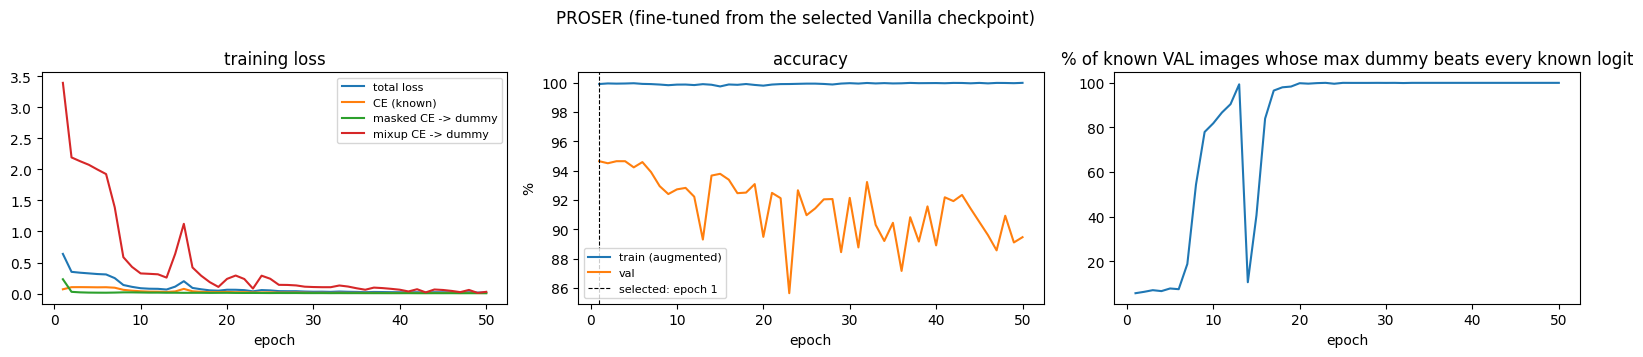

proser: best val acc 94.64% at epoch 1 / 50, last epoch 89.46%, 14.5 min on Tesla T4
Vanilla starting point: val acc 94.92%  ->  PROSER selected: 94.64% (epoch 1); known val images claimed by the dummy at that epoch: 5.68%
[D] saved /kaggle/working/outputs/task4_outputs.zip (11 files, 0.1 MB) and /kaggle/working/outputs/task4_checkpoints.zip (6 checkpoints, 256 MB)


In [9]:
t0 = time.time()
cfg = show_config('proser')
run(f'python -m task4.train --config task4/configs/proser.yaml --set {COMMON}')
TIMES['D proser'] = (time.time() - t0) / 60
h_p, s_p = show_history('proser', 'PROSER (fine-tuned from the selected Vanilla checkpoint)')
print(f"Vanilla starting point: val acc {s_v['best_val_acc']:.2f}%  ->  PROSER selected: {s_p['best_val_acc']:.2f}% "
      f"(epoch {s_p['best_epoch']}); known val images claimed by the dummy at that epoch: "
      f"{h_p.loc[h_p.epoch == s_p['best_epoch'], 'val_dummy_wins'].item():.2f}%")
save_outputs('D')

## Part E - extract CIFAR-10 outputs, compute thresholds, FREEZE

1. For each selected checkpoint, the 512-d penultimate feature f(x), the 10 logits z(x) and PROSER's 5 dummy
   logits are saved for the 45k train, 5k val and 10k test images. No augmentation, float32.
   - All scores later read these same arrays.
   - A built-in check recomputes validation accuracy from the saved logits and compares it with the checkpoint's
     recorded value.
2. `task4.freeze` uses the **train and val** outputs only:
   - Mahalanobis class means and the shared diagonal variance come from the unaugmented training features.
   - Every score gets a threshold: τ = 95th percentile of validation unknownness.
   - Everything is written to `results/frozen/frozen.json` with SHA-256 hashes. The pre-registered tables,
     comparisons and failure-selection rule go in the same record.

After this cell nothing that CIFAR-100 could influence can change without the code noticing.

In [10]:
t0 = time.time()
run(f'python -m task4.extract_outputs --stage known --skip-existing --set {COMMON}')
run(f'python -m task4.freeze --set {COMMON}')
TIMES['E extract+freeze'] = (time.time() - t0) / 60
rec = json.load(open(f'{FROZEN_DIR}/frozen.json'))
print(f"\nfrozen_at: {rec['frozen_at']}")
display(pd.DataFrame([{'model': r, 'epoch': c['epoch'], 'val acc %': c['val_acc'], 'checkpoint sha256': c['sha256'][:16] + '...'}
                      for r, c in rec['checkpoints'].items()]))
display(pd.DataFrame(rec['thresholds']).T.rename_axis('model').style.format('{:.6g}')
        .set_caption('thresholds tau (accept iff u <= tau)'))
display(pd.DataFrame(rec['val_acceptance']).T.round(2).rename_axis('model')
        .style.set_caption('% of validation images accepted (should be 95.00)'))
print('score definitions:')
for k, v in rec['score_definitions'].items():
    print(f'  {k:12s} {v}')
print('\nhashed files:', ', '.join(rec['code_sha256']))
print('CIFAR-100 on disk at freeze time:', os.path.exists(f'{DATA}/cifar-100-python'))
save_outputs('E')

$ python -m task4.extract_outputs --stage known --skip-existing --set data_root=/tmp/cifar cache_dir=/tmp/task4_cache
--- vanilla: /kaggle/working/PA1/task4/results/runs/vanilla/best.pt (epoch 96, recorded val acc 94.92%, dummies 0, sha256 da540bbd7fe5...)
  train:  45000 images | features (45000, 512) | accuracy of the 10 known logits 100.00% | 22s
  val  :   5000 images | features (5000, 512) | accuracy of the 10 known logits  94.92% | 3s
  test :  10000 images | features (10000, 512) | accuracy of the 10 known logits  94.40% | 6s
  check: val accuracy from the saved logits vs the checkpoint's recorded val accuracy: identical
--- gcsc: /kaggle/working/PA1/task4/results/runs/gcsc/best.pt (epoch 96, recorded val acc 95.40%, dummies 0, sha256 f064d95b024a...)
  train:  45000 images | features (45000, 512) | accuracy of the 10 known logits  99.98% | 22s
  val  :   5000 images | features (5000, 512) | accuracy of the 10 known logits  95.40% | 3s
  test :  10000 images | features (10000, 5

,model,epoch,val acc %,checkpoint sha256
0,vanilla,96,94.92,da540bbd7fe5b3ef...
1,gcsc,96,95.40,f064d95b024a4f00...
2,proser,1,94.64,27526c6298d05809...


,msp,mls,energy,mahalanobis,proser
model,,,,,
vanilla,0.180287,-5.77559,-5.96739,3058.25,nan
gcsc,0.184716,-6.01014,-6.21709,1991.01,nan
proser,0.252465,-3.57715,-3.87951,2929.22,1.60289e-05


,msp,mls,energy,mahalanobis,proser
model,,,,,
vanilla,95.000000,95.000000,95.000000,95.000000,nan
gcsc,95.000000,95.000000,95.000000,95.000000,nan
proser,95.000000,95.000000,95.000000,95.000000,95.000000


score definitions:
  msp          u = 1 - max_k softmax(z)_k  (10 known logits; computed exactly in float64)
  mls          u = - max_k z_k  (10 known logits)
  energy       u = - logsumexp_k z_k  (10 known logits, T = 1)
  mahalanobis  u = min_c sum_d (f_d - mu_cd)^2 / (sigma_d^2 + 1e-6); mu_c, sigma^2 = class means and pooled within-class variance of UNAUGMENTED 45k CIFAR-10 training features
  proser       u = p_dummy - max_k p_k, p = softmax([z, max_j d_j] / 1024)  (PROSER reference code)

hashed files: task4/scores/__init__.py, task4/scores/msp.py, task4/scores/mls.py, task4/scores/energy.py, task4/scores/mahalanobis.py, task4/scores/proser_detection.py, task4/evaluation/thresholds.py, task4/configs/proser.yaml, task4/models/resnet_cifar.py, task4/data/cifar10.py, task4/extract_outputs.py, task4/data/cifar100_unknowns.py
CIFAR-100 on disk at freeze time: False
[E] saved /kaggle/working/outputs/task4_outputs.zip (15 files, 0.3 MB) and /kaggle/working/outputs/task4_checkpoints.zip (

In [11]:
# E2. Reproducibility check against RUN 1 (the interactive run whose files were lost; task4/run1/). Same code, seed,
# GPU type and data. If training is bit-for-bit deterministic, the checkpoint hashes match run 1's printed prefixes.
run1 = json.load(open('task4/run1/run1_key_numbers.json'))
rows = []
for r, c in rec['checkpoints'].items():
    o = run1['checkpoints'][r]
    rows.append({'model': r, 'run1 epoch': o['epoch'], 'run2 epoch': c['epoch'], 'run1 val acc': o['val_acc'],
                 'run2 val acc': round(c['val_acc'], 2), 'run1 sha256': o['sha256_prefix'],
                 'run2 sha256': c['sha256'][:16], 'bit-identical': c['sha256'][:16] == o['sha256_prefix']})
display(pd.DataFrame(rows))
print(f"split: run 1 {run1['split_sha256_prefix']}...  run 2 {split['sha256'][:16]}...  "
      f"{'identical' if split['sha256'].startswith(run1['split_sha256_prefix']) else 'DIFFERENT'}")
print(f"environment: run 1 {run1['environment']}\n             run 2 { {k: ENV.get(k) for k in ('gpu', 'torch', 'torchvision', 'cudnn')} }")
same = all(r['bit-identical'] for r in rows)
print('\nAll three checkpoints are bit-identical to run 1: the run reproduced exactly.' if same else
      '\nNot bit-identical to run 1. Compare the validation accuracies above and the tables in F2: small differences '
      'come from GPU non-determinism or a changed Kaggle image, and are reported as run-to-run variation.')

,model,run1 epoch,run2 epoch,run1 val acc,run2 val acc,run1 sha256,run2 sha256,bit-identical
0,vanilla,96,96,94.92,94.92,da540bbd7fe5b3ef,da540bbd7fe5b3ef,True
1,gcsc,96,96,95.40,95.40,f064d95b024a4f00,f064d95b024a4f00,True
2,proser,1,1,94.64,94.64,27526c6298d05809,27526c6298d05809,True


split: run 1 456aac6ee532f72c...  run 2 456aac6ee532f72c...  identical
environment: run 1 {'gpu': 'Tesla T4', 'torch': '2.10.0+cu128', 'torchvision': '0.25.0+cu128', 'cudnn': 91002}
             run 2 {'gpu': 'Tesla T4', 'torch': '2.10.0+cu128', 'torchvision': '0.25.0+cu128', 'cudnn': 91002}

All three checkpoints are bit-identical to run 1: the run reproduced exactly.


## Part F - FIRST CIFAR-100 access: unknown outputs and evaluation

Only the CIFAR-100 **test** split is opened, and only the 16 fixed classes:
- near: bus, pickup_truck, motorcycle, tractor, wolf, fox, leopard, camel;
- far: bottle, bowl, chair, clock, keyboard, mushroom, sunflower, wardrobe;
- 100 images each, 800 per group.

The loader re-verifies the freeze record first and logs the access.

How to read the tables:
- **AUROC:** threshold-free ranking quality for Known vs Near / Far / All. 50 = chance, 100 = perfect.
- **test_accept:** % of CIFAR-10 test images accepted at the frozen τ. It should be close to 95.
- **reject_near / reject_far:** % of unknowns rejected at the same τ.
- **FPR95:** % of unknowns wrongly accepted, which is 100 − rejection (the handout's FPR@95TPR convention).
- **CSA:** closed-set accuracy on the 10 known logits, before any rejection.
- **Uncertainty:**
  - AUROC 95% CIs come from 2,000 stratified bootstrap resamples. Model/score differences are paired on the same
    resamples.
  - Rejection and CSA differences use exact McNemar tests.
  - Holm correction is applied within each pre-registered family.

In [12]:
t0 = time.time()
from task4.data.cifar100_unknowns import download_cifar100
attach_if_valid(datasets.CIFAR100)          # an attached copy is used only if all MD5 checksums match
download_cifar100(DATA)
run(f'python -m task4.extract_outputs --stage unknown --skip-existing --set {COMMON}')
run(f'python -m task4.evaluate_osr --set {COMMON}')
TIMES['F evaluate'] = (time.time() - t0) / 60
save_outputs('F')

cifar-100-python: no valid attached copy - downloading from the official source


100%|██████████| 169M/169M [51:35<00:00, 54.6kB/s]


$ python -m task4.extract_outputs --stage unknown --skip-existing --set data_root=/tmp/cifar cache_dir=/tmp/task4_cache
freeze record verified: 3 checkpoints, 12 code files, 3 Mahalanobis statistics files unchanged since 2026-09-21T07:35:54+00:00
CIFAR-100 unknowns loaded (1600 images). Access #1; freeze 2026-09-21T07:35:54+00:00 <= first access 2026-09-21T08:27:39+00:00
--- vanilla: /kaggle/working/PA1/task4/results/runs/vanilla/best.pt (epoch 96, recorded val acc 94.92%, dummies 0, sha256 da540bbd7fe5...)
  unknown: 1600 images (near 800, far 800) | 1s
--- gcsc: /kaggle/working/PA1/task4/results/runs/gcsc/best.pt (epoch 96, recorded val acc 95.40%, dummies 0, sha256 f064d95b024a...)
  unknown: 1600 images (near 800, far 800) | 1s
--- proser: /kaggle/working/PA1/task4/results/runs/proser/best.pt (epoch 1, recorded val acc 94.64%, dummies 5, sha256 27526c6298d0...)
  unknown: 1600 images (near 800, far 800) | 1s
  [0.2 min]
$ python -m task4.evaluate_osr --set data_root=/tmp/cifar cach

In [13]:
# The two required tables (numbers in %), with their uncertainty.
t1 = pd.read_csv(f'{FINAL_DIR}/table1_posthoc_scores_vanilla.csv')
t2 = pd.read_csv(f'{FINAL_DIR}/table2_models_mls.csv')
main_cols = ['model', 'score', 'CSA', 'AUROC_near', 'AUROC_far', 'AUROC_all', 'test_accept', 'reject_near', 'reject_far',
             'FPR95_near', 'FPR95_far', 'FPR95_all']
ci_cols = ['model', 'score', 'AUROC_near_CI', 'AUROC_far_CI', 'AUROC_all_CI', 'test_accept_CI', 'reject_near_CI',
           'reject_far_CI']
print('TABLE 1 - MSP / MLS / Energy / Mahalanobis on the frozen Vanilla model'); display(t1[main_cols].round(2))
display(t1[ci_cols])
print('TABLE 2 - Vanilla vs GCSC vs PROSER with MLS, + PROSER placeholder-based detection'); display(t2[main_cols].round(2))
display(t2[ci_cols])
comp = pd.read_csv(f'{FINAL_DIR}/auroc_comparisons.csv')
print('Paired AUROC differences A - B (bootstrap 95% CI, Holm-adjusted p within table x group)')
display(comp.round(3))
print('Rejection at the frozen thresholds: paired exact McNemar (only_A_rejects / only_B_rejects = discordant images)')
display(pd.read_csv(f'{FINAL_DIR}/rejection_mcnemar.csv').round(4))
print('Closed-set accuracy: paired exact McNemar on the 10,000 test images')
display(pd.read_csv(f'{FINAL_DIR}/csa_mcnemar.csv').round(4))

TABLE 1 - MSP / MLS / Energy / Mahalanobis on the frozen Vanilla model


,model,score,CSA,AUROC_near,AUROC_far,AUROC_all,test_accept,reject_near,reject_far,FPR95_near,FPR95_far,FPR95_all
0,vanilla,MSP,94.4,80.96,90.25,85.61,95.17,25.62,42.25,74.38,57.75,66.06
1,vanilla,MLS,94.4,79.11,90.14,84.63,95.32,30.00,54.88,70.00,45.12,57.56
2,vanilla,Energy,94.4,79.13,90.25,84.69,95.42,30.12,55.62,69.88,44.38,57.12
3,vanilla,Mahalanobis,94.4,79.57,92.18,85.88,95.11,26.50,50.88,73.50,49.12,61.31


,model,score,AUROC_near_CI,AUROC_far_CI,AUROC_all_CI,test_accept_CI,reject_near_CI,reject_far_CI
0,vanilla,MSP,"[79.35, 82.50]","[89.30, 91.17]","[84.61, 86.55]","[94.73, 95.57]","[22.7, 28.8]","[38.9, 45.7]"
1,vanilla,MLS,"[77.29, 80.83]","[88.95, 91.26]","[83.50, 85.70]","[94.89, 95.72]","[26.9, 33.3]","[51.4, 58.3]"
2,vanilla,Energy,"[77.32, 80.86]","[89.05, 91.38]","[83.56, 85.76]","[94.99, 95.81]","[27.0, 33.4]","[52.2, 59.0]"
3,vanilla,Mahalanobis,"[77.87, 81.23]","[91.38, 92.91]","[84.91, 86.85]","[94.67, 95.52]","[23.6, 29.7]","[47.4, 54.3]"


TABLE 2 - Vanilla vs GCSC vs PROSER with MLS, + PROSER placeholder-based detection


,model,score,CSA,AUROC_near,AUROC_far,AUROC_all,test_accept,reject_near,reject_far,FPR95_near,FPR95_far,FPR95_all
0,vanilla,MLS,94.40,79.11,90.14,84.63,95.32,30.00,54.88,70.00,45.12,57.56
1,gcsc,MLS,95.14,80.54,90.85,85.69,95.35,34.88,55.38,65.12,44.62,54.88
2,proser,MLS,94.26,79.37,88.90,84.14,95.34,25.25,47.88,74.75,52.12,63.44
3,proser,PROSER-detect,94.26,78.62,87.74,83.18,95.33,24.62,43.75,75.38,56.25,65.81


...

,table,group,A,B,AUROC_A_minus_B,CI_low,CI_high,p_boot,p_holm,significant_0.05
0,table1,near,vanilla-MSP,vanilla-MLS,1.854,1.334,2.412,0.001,0.006,True
1,table1,near,vanilla-MSP,vanilla-Energy,1.830,1.301,2.397,0.001,0.006,True
2,table1,near,vanilla-MSP,vanilla-Mahalanobis,1.390,0.466,2.274,0.008,0.032,True
3,table1,near,vanilla-MLS,vanilla-Energy,-0.024,-0.060,0.013,0.180,0.540,False
4,table1,near,vanilla-MLS,vanilla-Mahalanobis,-0.464,-1.614,0.638,0.432,0.864,False
5,table1,near,vanilla-Energy,vanilla-Mahalanobis,-0.440,-1.599,0.665,0.458,0.864,False
6,table1,far,vanilla-MSP,vanilla-MLS,0.106,-0.371,0.564,0.647,1.000,False
7,table1,far,vanilla-MSP,vanilla-Energy,0.001,-0.482,0.472,0.992,1.000,False
8,table1,far,vanilla-MSP,vanilla-Mahalanobis,-1.934,-2.444,-1.450,0.001,0.006,True
9,table1,far,vanilla-MLS,vanilla-Energy,-0.105,-0.143,-0.065,0.001,0.006,True


Rejection at the frozen thresholds: paired exact McNemar (only_A_rejects / only_B_rejects = discordant images)


,table,group,A,B,reject_A,reject_B,only_A_rejects,only_B_rejects,p_exact,p_holm,significant_0.05
0,table1,near,vanilla-MSP,vanilla-MLS,25.625,30.000,29,64,0.0004,0.0022,True
1,table1,near,vanilla-MSP,vanilla-Energy,25.625,30.125,34,70,0.0005,0.0027,True
2,table1,near,vanilla-MSP,vanilla-Mahalanobis,25.625,26.500,20,27,0.3817,0.7634,False
3,table1,near,vanilla-MLS,vanilla-Energy,30.000,30.125,5,6,1.0000,1.0000,False
4,table1,near,vanilla-MLS,vanilla-Mahalanobis,30.000,26.500,70,42,0.0104,0.0399,True
5,table1,near,vanilla-Energy,vanilla-Mahalanobis,30.125,26.500,74,45,0.0100,0.0399,True
6,table1,far,vanilla-MSP,vanilla-MLS,42.250,54.875,18,119,0.0000,0.0000,True
7,table1,far,vanilla-MSP,vanilla-Energy,42.250,55.625,25,132,0.0000,0.0000,True
8,table1,far,vanilla-MSP,vanilla-Mahalanobis,42.250,50.875,19,88,0.0000,0.0000,True
9,table1,far,vanilla-MLS,vanilla-Energy,54.875,55.625,7,13,0.2632,0.2632,False


Closed-set accuracy: paired exact McNemar on the 10,000 test images


,A,B,CSA_A,CSA_B,diff,only_A_correct,only_B_correct,p_exact,p_holm,significant_0.05
0,gcsc,vanilla,95.14,94.40,0.74,266,192,0.0006,0.0013,True
1,proser,vanilla,94.26,94.40,-0.14,74,88,0.3071,0.3071,False
2,proser,gcsc,94.26,95.14,-0.88,192,280,0.0001,0.0002,True


In [14]:
# F2. Tables 1 and 2: run 2 (this run) next to run 1 (recovered, 2 decimals). Differences are run-to-run variation.
cols = ['CSA', 'AUROC_near', 'AUROC_far', 'AUROC_all', 'test_accept', 'reject_near', 'reject_far']
for name, now_t, old in (('Table 1', t1, run1['table1']), ('Table 2', t2, run1['table2'])):
    old = pd.DataFrame(old).set_index(['model', 'score'])[cols]
    new = now_t.set_index(['model', 'score'])[cols].round(2)
    print(f'{name}: run 2 minus run 1 (points)')
    display((new - old).round(2))

Table 1: run 2 minus run 1 (points)


CSA  AUROC_near  AUROC_far  AUROC_all  test_accept  reject_near  reject_far
model   score                                                                                   
vanilla MSP          0.0         0.0        0.0        0.0          0.0          0.0         0.0
        MLS          0.0         0.0        0.0        0.0          0.0          0.0         0.0
        Energy       0.0         0.0        0.0        0.0          0.0          0.0         0.0
        Mahalanobis  0.0         0.0        0.0        0.0          0.0          0.0         0.0

Table 2: run 2 minus run 1 (points)


CSA  AUROC_near  AUROC_far  AUROC_all  test_accept  reject_near  reject_far
model   score                                                                                     
vanilla MLS            0.0         0.0        0.0        0.0          0.0          0.0         0.0
gcsc    MLS            0.0         0.0        0.0        0.0          0.0          0.0         0.0
proser  MLS            0.0         0.0        0.0        0.0          0.0          0.0         0.0
        PROSER-detect  0.0         0.0        0.0        0.0          0.0          0.0         0.0

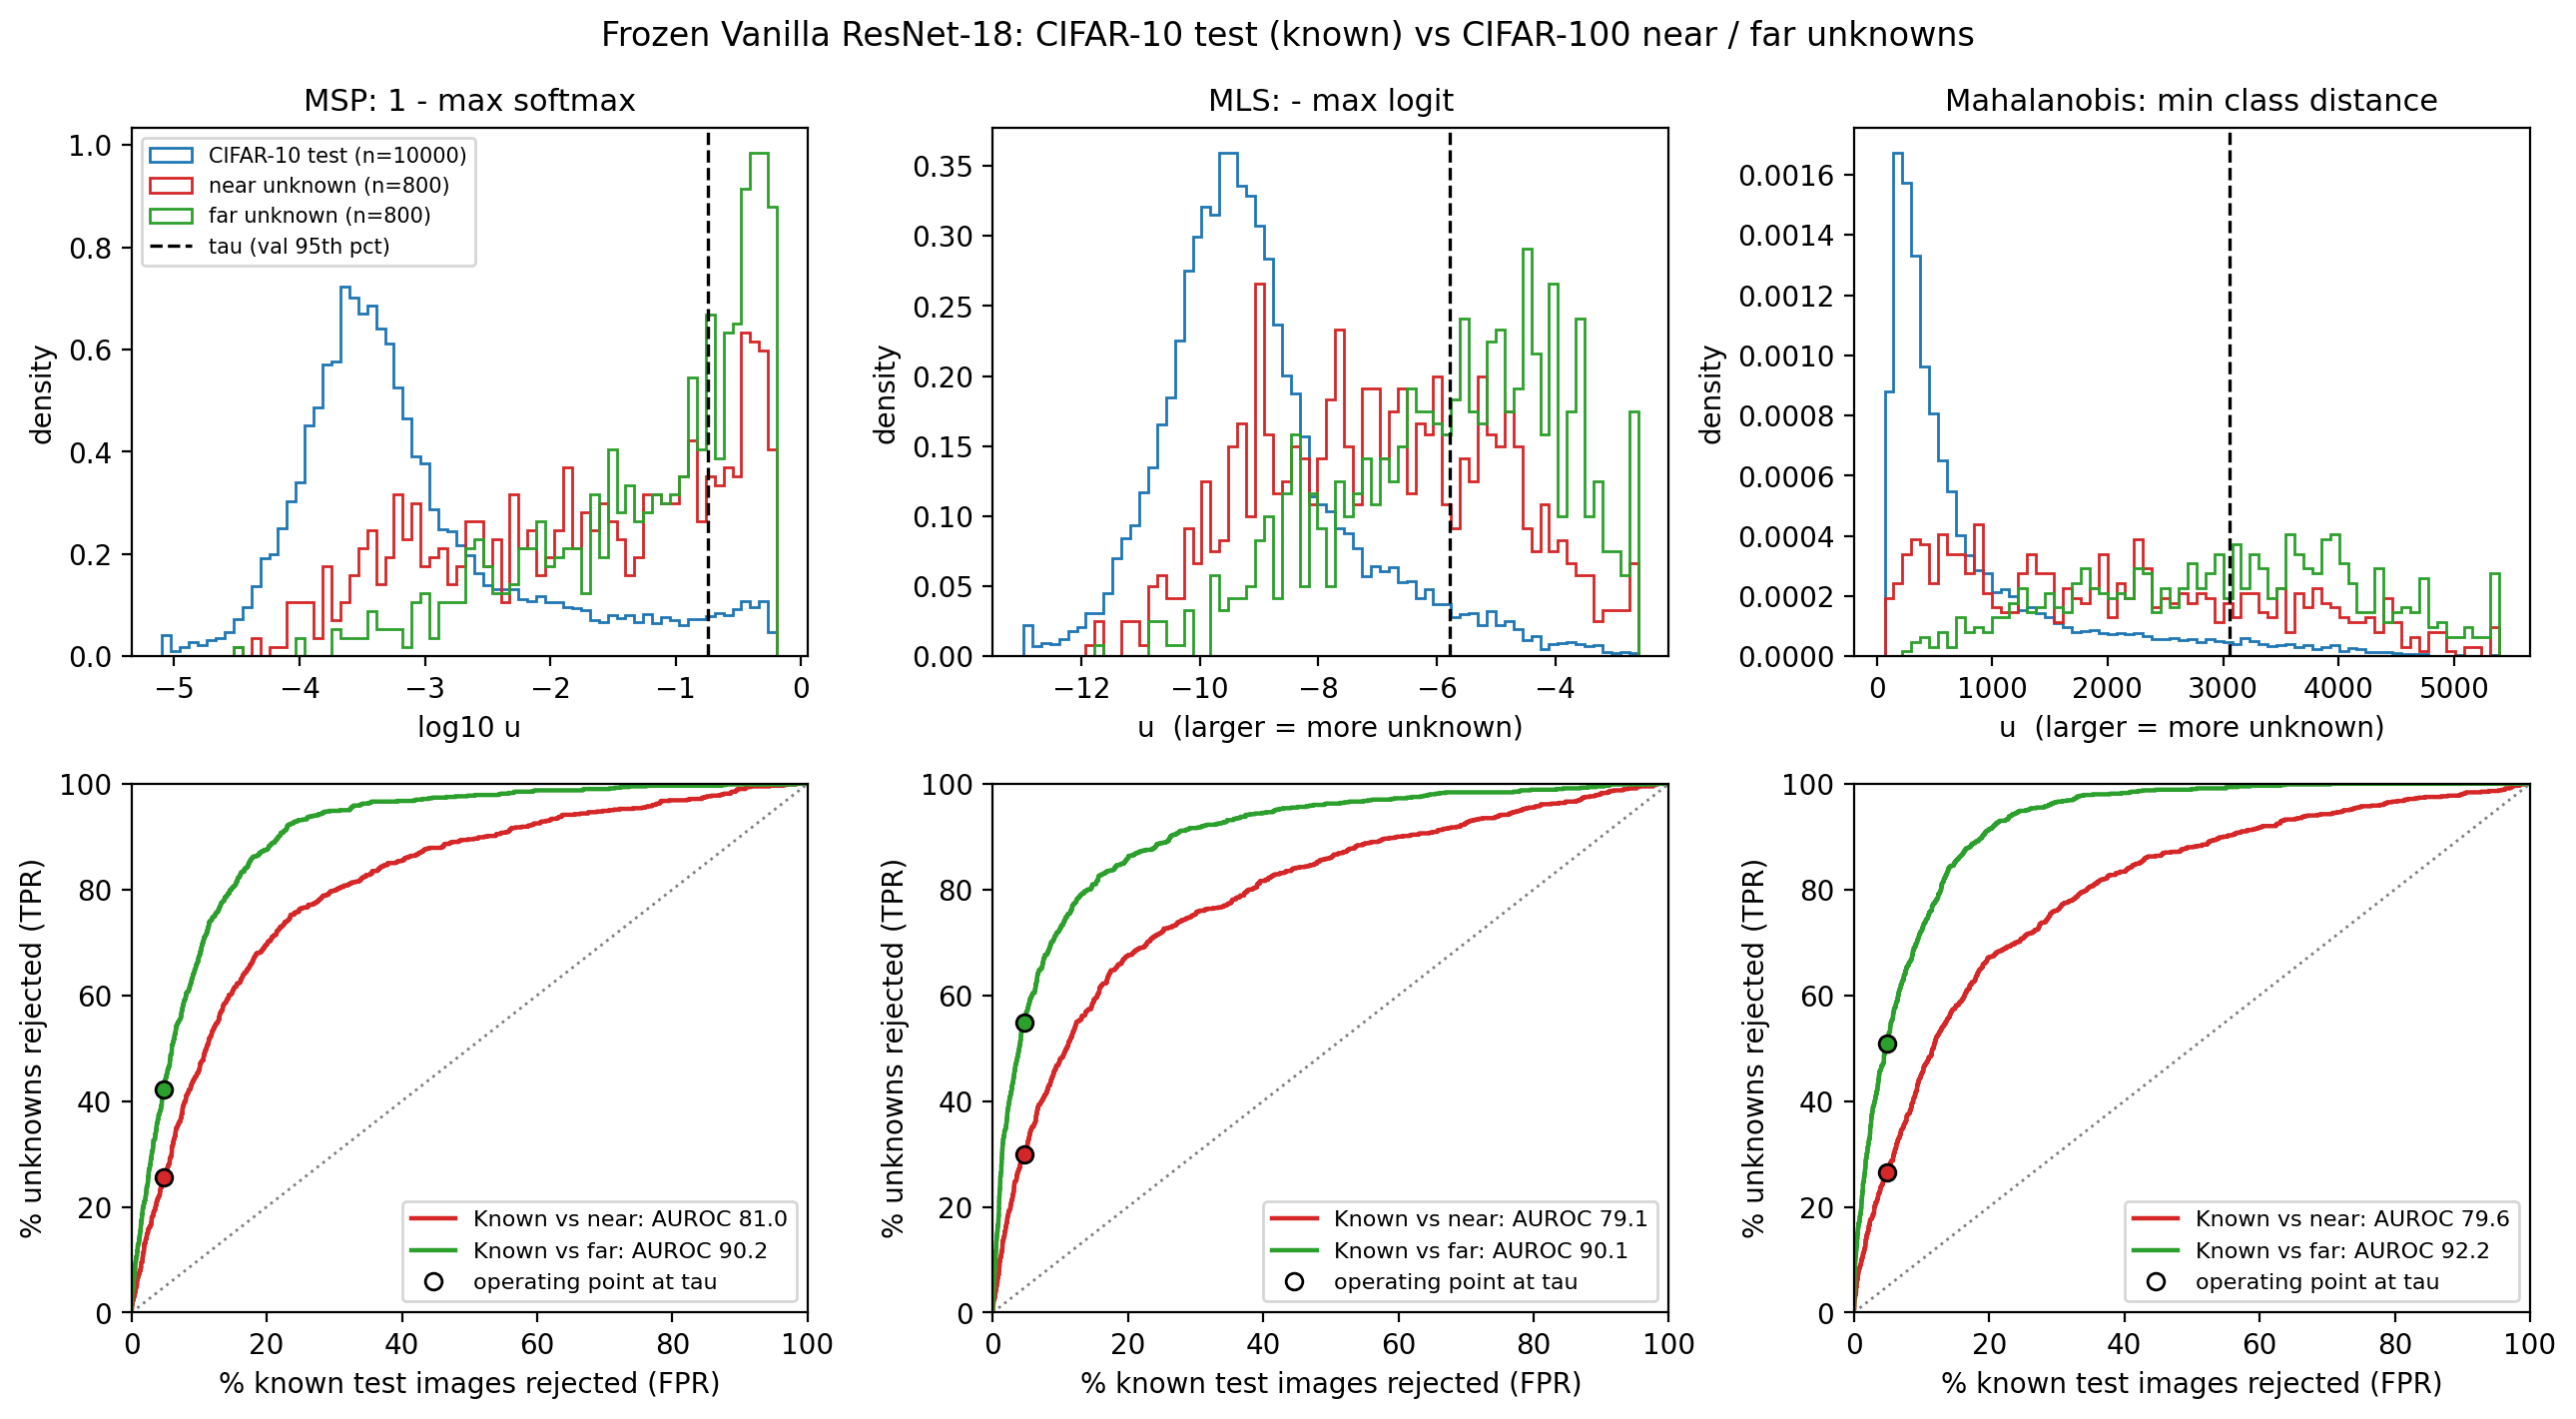

Spearman rank correlation between the Vanilla scores, within each set of images


set                   far  known_test   near
A      B                                    
Energy Mahalanobis  0.754       0.448  0.885
MLS    Energy       0.994       1.000  0.998
       Mahalanobis  0.790       0.449  0.899
MSP    Energy       0.880       0.952  0.932
       MLS          0.919       0.952  0.949
       Mahalanobis  0.895       0.588  0.954

Which unknowns each pair of scores rejects (% of the group)


,group,A,B,both_reject_%,only_A_rejects_%,only_B_rejects_%,both_accept_%
0,near,MSP,MLS,22.0,3.6,8.0,66.4
1,near,MSP,Energy,21.4,4.2,8.8,65.6
2,near,MSP,Mahalanobis,23.1,2.5,3.4,71.0
3,near,MLS,Energy,29.4,0.6,0.8,69.2
4,near,MLS,Mahalanobis,21.2,8.8,5.2,64.8
5,near,Energy,Mahalanobis,20.9,9.2,5.6,64.2
6,far,MSP,MLS,40.0,2.2,14.9,42.9
7,far,MSP,Energy,39.1,3.1,16.5,41.2
8,far,MSP,Mahalanobis,39.9,2.4,11.0,46.8
9,far,MLS,Energy,54.0,0.9,1.6,43.5


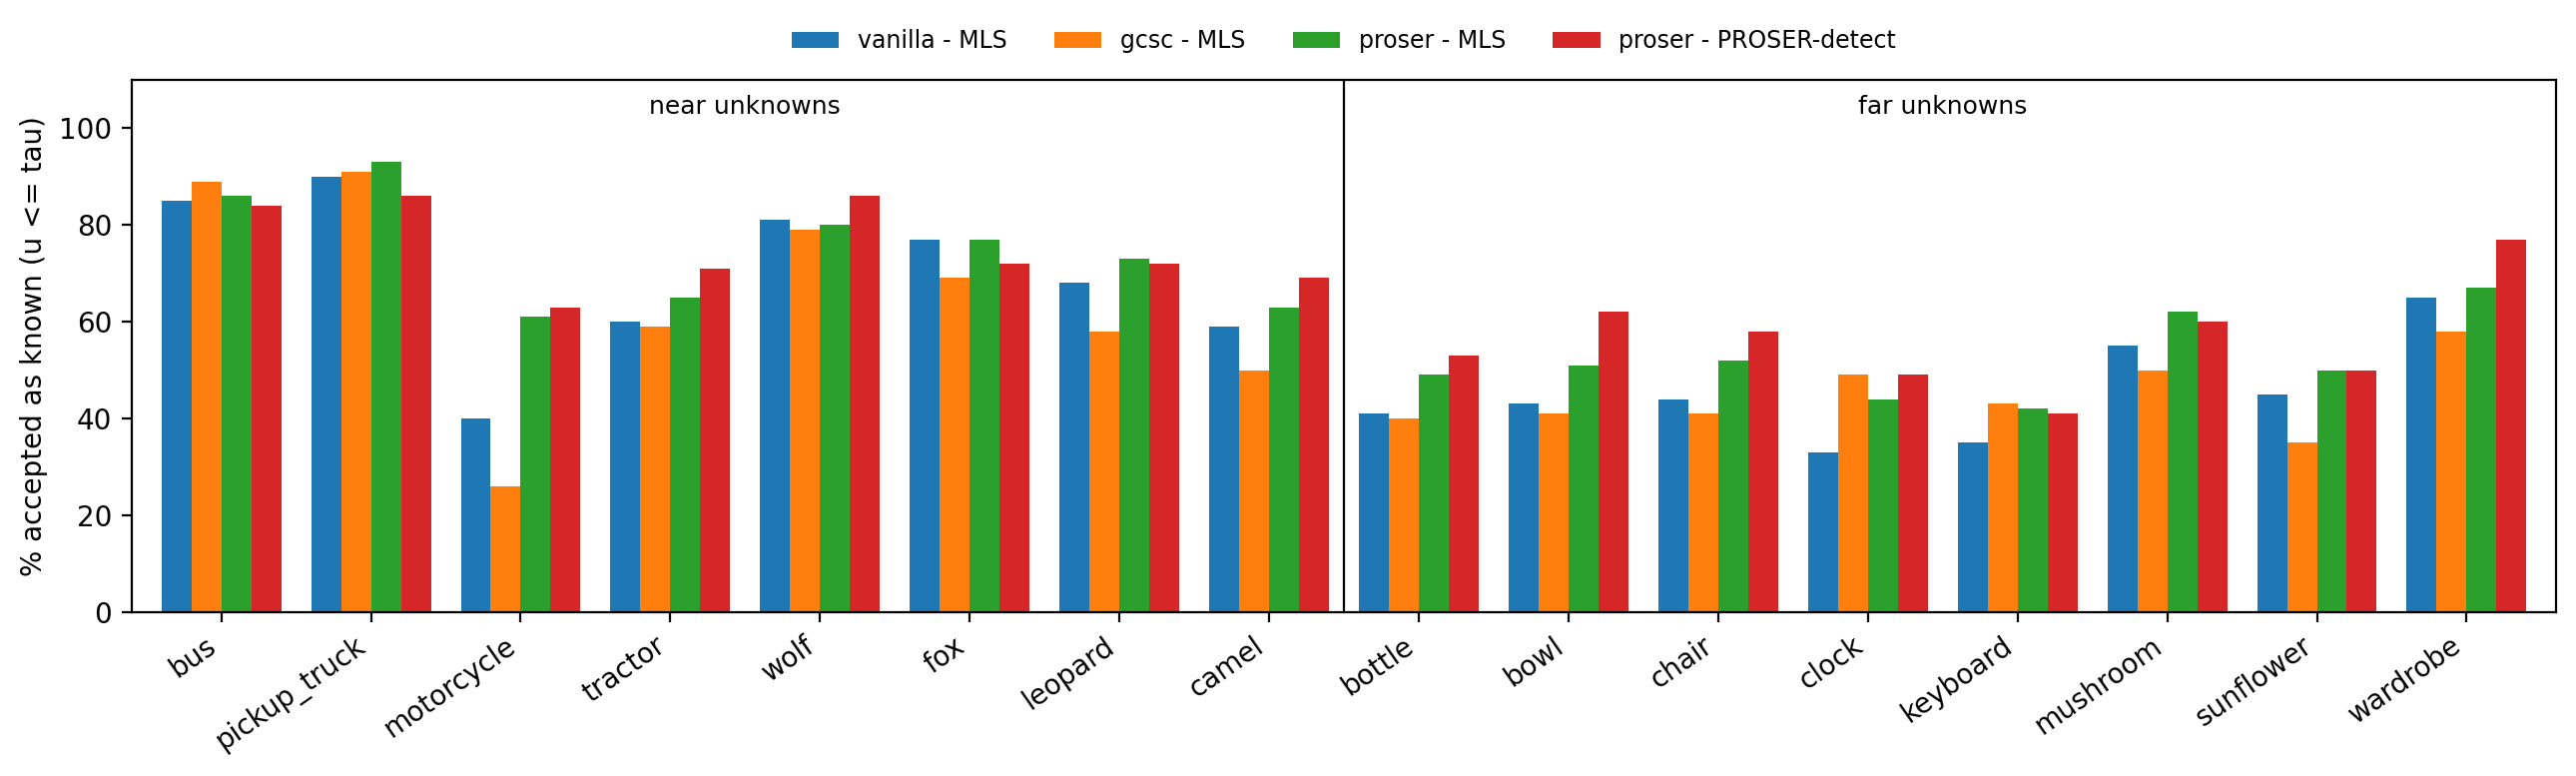

row                 vanilla-MSP  vanilla-MLS  vanilla-Energy  vanilla-Mahalanobis  gcsc-MLS  proser-MLS  proser-PROSER-detect
group class                                                                                                                  
near  bus                  86.0         85.0            86.0                 86.0      89.0        86.0                  84.0
      pickup_truck         86.0         90.0            90.0                 87.0      91.0        93.0                  86.0
      motorcycle           53.0         40.0            38.0                 45.0      26.0        61.0                  63.0
      tractor              67.0         60.0            58.0                 66.0      59.0        65.0                  71.0
      wolf                 87.0         81.0            82.0                 90.0      79.0        80.0                  86.0
      fox                  76.0         77.0            77.0                 75.0      69.0        77.0                  72.0
      leopard              75.0         68.0            69.0                 76.0      58.0        73.0                  72.0
      camel                65.0         59.0            59.0                 63.0      50.0        63.0                  69.0
far   bottle               56.0         41.0            40.0                 45.0      40.0        49.0                  53.0
      bowl                 56.0         43.0            41.0                 47.0      41.0        51.0                  62.0
      chair                62.0         44.0            42.0                 52.0      41.0        52.0                  58.0
      clock                52.0         33.0            33.0                 39.0      49.0        44.0                  49.0
      keyboard             47.0         35.0            33.0                 42.0      43.0        42.0                  41.0
      mushroom             62.0         55.0            54.0                 62.0      50.0        62.0                  60.0
      sunflower            56.0         45.0            45.0                 49.0      35.0        50.0                  50.0
      wardrobe             71.0         65.0            67.0                 57.0      58.0        67.0                  77.0

Top absorbing CIFAR-10 class of the ACCEPTED images (Vanilla-MLS):


,group,class,accepted_%,top_absorber,top_absorber_share_%,argmax_all_images
16,near,bus,85.0,truck,81.2,truck
17,near,pickup_truck,90.0,automobile,67.8,automobile
18,near,motorcycle,40.0,automobile,52.5,automobile
19,near,tractor,60.0,truck,71.7,truck
20,near,wolf,81.0,cat,53.1,cat
21,near,fox,77.0,cat,40.3,cat
22,near,leopard,68.0,cat,38.2,cat
23,near,camel,59.0,deer,30.5,horse
24,far,bottle,41.0,cat,34.2,cat
25,far,bowl,43.0,cat,32.6,cat


In [15]:
# Required figure: score distributions + ROC for MSP, MLS and Mahalanobis on the frozen Vanilla model.
display(Image(f'{FINAL_DIR}/figures/fig_vanilla_scores.png', width=1100))
# Research question 2 - where do the four scores agree and disagree?
print('Spearman rank correlation between the Vanilla scores, within each set of images')
display(pd.read_csv(f'{FINAL_DIR}/score_agreement_spearman.csv').pivot_table(index=['A', 'B'], columns='set',
        values='spearman').round(3))
print('Which unknowns each pair of scores rejects (% of the group)')
display(pd.read_csv(f'{FINAL_DIR}/decision_overlap_unknowns.csv').round(1))
# Research questions 1, 3, 4 - per-class acceptance and which CIFAR-10 class absorbs each unknown class.
display(Image(f'{FINAL_DIR}/figures/fig_acceptance_by_class.png', width=1100))
pc = pd.read_csv(f'{FINAL_DIR}/acceptance_by_class.csv')
pc['row'] = pc['model'] + '-' + pc['score']
display(pc.pivot_table(index=['group', 'class'], columns='row', values='accepted_%', sort=False).round(1))
print('Top absorbing CIFAR-10 class of the ACCEPTED images (Vanilla-MLS):')
display(pc[(pc.model == 'vanilla') & (pc.score == 'MLS')][['group', 'class', 'accepted_%', 'top_absorber',
        'top_absorber_share_%', 'argmax_all_images']].round(1))

## Part G - failure analysis (Vanilla-MLS threshold)

These are the unknowns that Vanilla accepts as known under its **frozen** MLS threshold. Every selection rule
below was fixed before any result existed and is read from the freeze record.
- For each image, the tables record what the handout asks for: the unknown class, the predicted CIFAR-10 class,
  the score and the threshold.
- Nothing is labelled plausible or surprising: **that judgement is yours.**
- Every view adds its images to one shared sheet, `failures/your_judgement.csv`, with blank `your_call` /
  `your_reason` columns. Its `in_views` column says which views show each image. Rows are only ever added, so
  your entries are never overwritten.
- None of this feeds back into any model, score or threshold.

### G1. Main selection (the required evidence)
The most confidently accepted image of each unknown class: first 6 per group, at least 3.

$ python -m task4.evaluation.failure_analysis --view main --set data_root=/tmp/cifar cache_dir=/tmp/task4_cache
/kaggle/working/PA1/task4/evaluation/failure_analysis.py:129: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  j = pd.concat([j, pd.DataFrame([{**r.to_dict(), "in_views": view, "your_call": "", "your_reason": ""}])],
your_judgement.csv: 12 new row(s) from view 'main'; 12 rows in total, 0 already judged (your entries are never overwritten)
freeze record verified: 3 checkpoints, 12 code files, 3 Mahalanobis statistics files unchanged since 2026-09-21T07:35:54+00:00
CIFAR-100 unknowns loaded (1600 images). Access #2; freeze 2026-09-21T07:35:54+00:00 <= first access 2026-09-21T08:27:39+00:00

view: main
rule: Among unknowns ACCEPTED by V

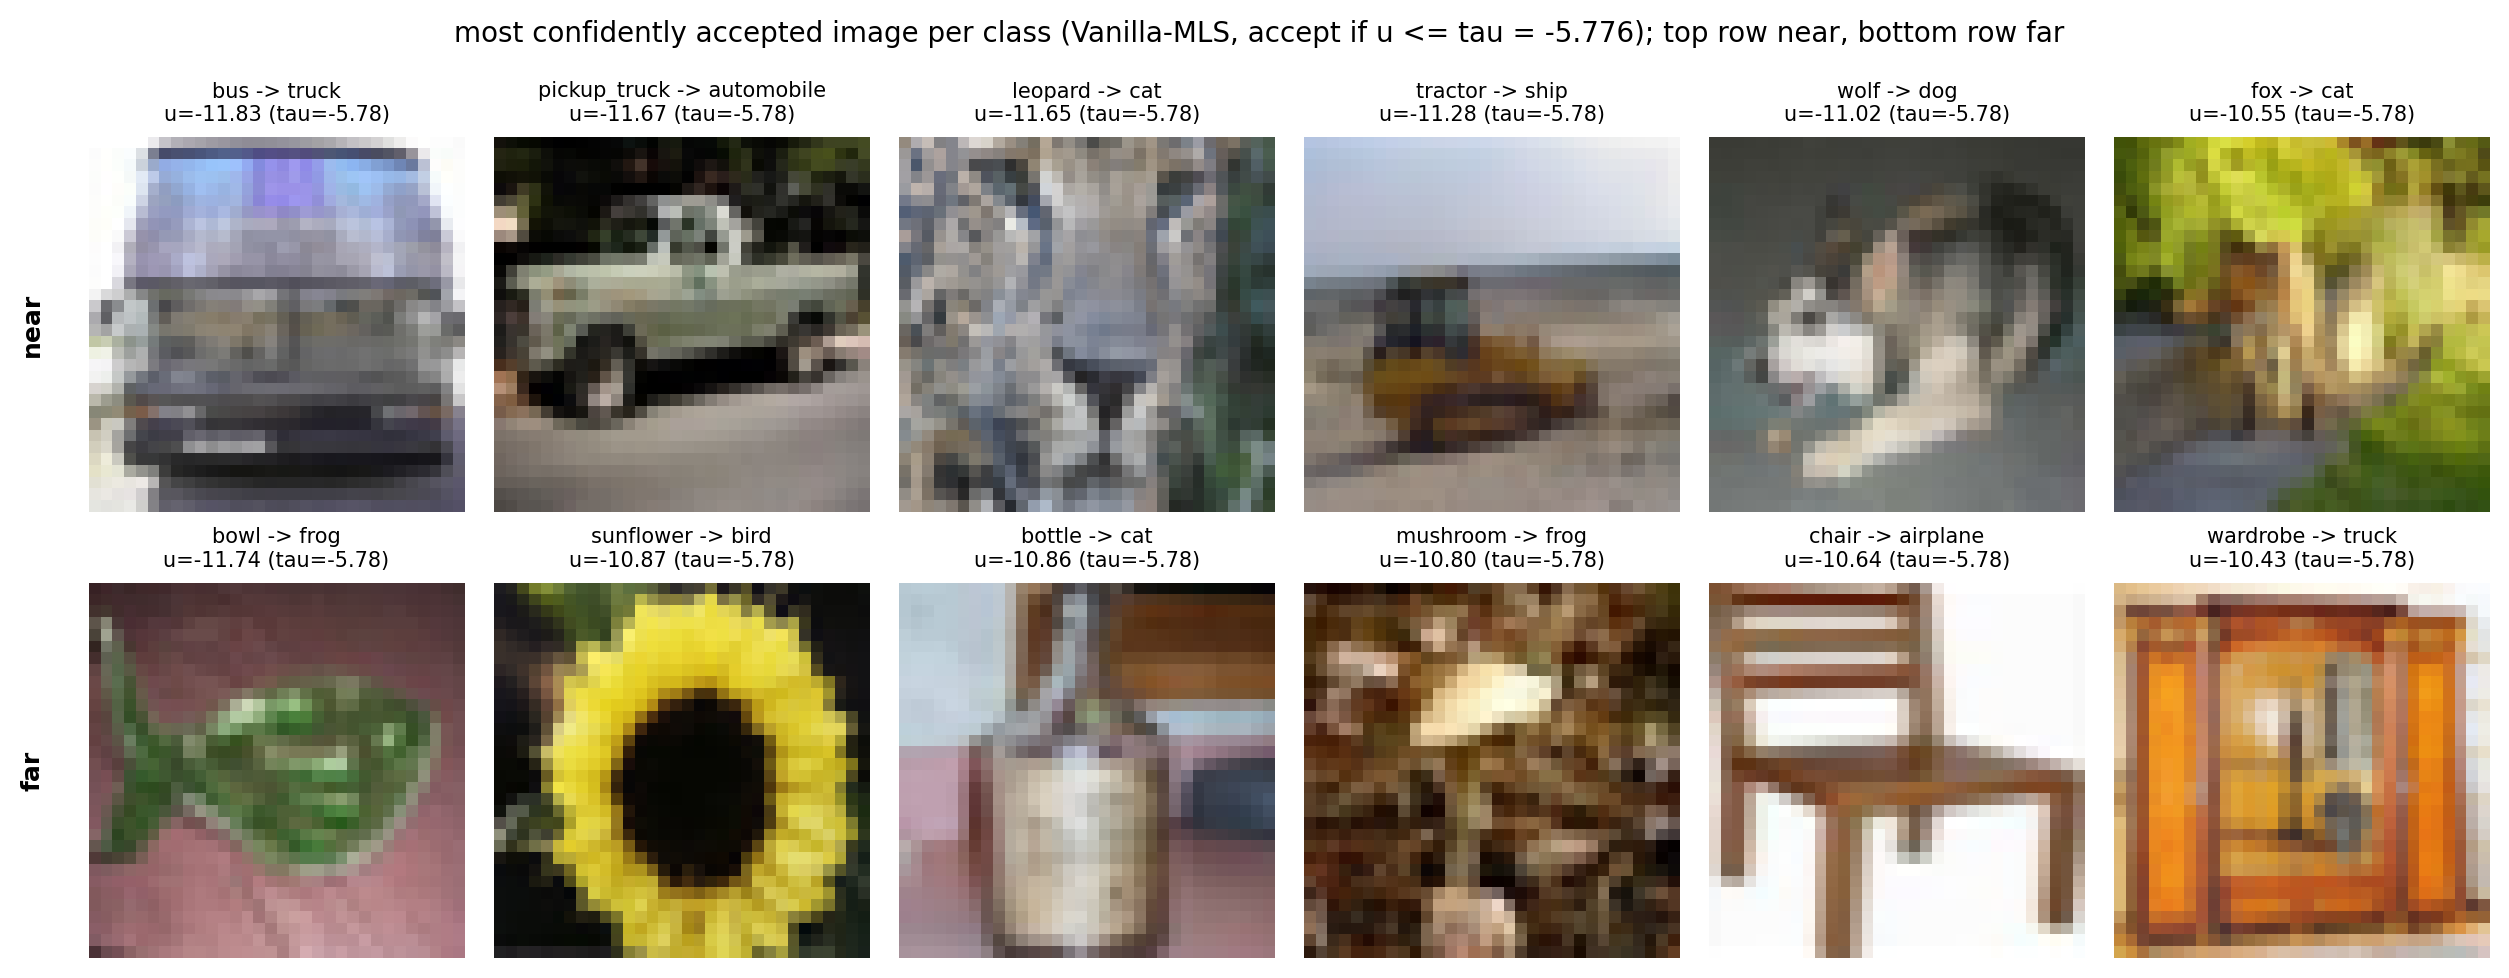

Selected failures (pre-registered rule):


,group,fine_class,index,pred,second_choice,u,tau,margin_below_tau,max_logit,max_softmax
0,near,bus,5201,truck,automobile,-11.834,-5.776,6.058,11.834,1.000
1,near,pickup_truck,9081,automobile,truck,-11.672,-5.776,5.896,11.672,1.000
2,near,leopard,6055,cat,bird,-11.646,-5.776,5.870,11.646,1.000
3,near,tractor,8996,ship,truck,-11.280,-5.776,5.504,11.280,1.000
4,near,wolf,720,dog,cat,-11.022,-5.776,5.246,11.022,1.000
5,near,fox,4706,cat,deer,-10.549,-5.776,4.774,10.549,1.000
6,far,bowl,9561,frog,cat,-11.737,-5.776,5.962,11.737,1.000
7,far,sunflower,5260,bird,cat,-10.865,-5.776,5.090,10.865,1.000
8,far,bottle,3888,cat,bird,-10.857,-5.776,5.082,10.857,1.000
9,far,mushroom,3502,frog,deer,-10.797,-5.776,5.021,10.797,1.000


How many of each class's 100 images Vanilla-MLS accepted, and which CIFAR-10 classes absorbed them:


,group,class,accepted_of_100,absorbed_by
0,near,bus,85,"truck 69, automobile 13, airplane 1"
1,near,pickup_truck,90,"automobile 61, truck 29"
2,near,motorcycle,40,"automobile 21, truck 10, airplane 6"
3,near,tractor,60,"truck 43, ship 7, automobile 5"
4,near,wolf,81,"cat 43, dog 32, deer 4"
5,near,fox,77,"cat 31, deer 30, dog 11"
6,near,leopard,68,"cat 26, frog 25, deer 12"
7,near,camel,59,"deer 18, dog 15, horse 15"
8,far,bottle,41,"cat 14, ship 14, truck 7"
9,far,bowl,43,"cat 14, frog 7, automobile 7"


[G1] saved /kaggle/working/outputs/task4_outputs.zip (47 files, 2.1 MB) and /kaggle/working/outputs/task4_checkpoints.zip (6 checkpoints, 256 MB)
[G1] saved /kaggle/working/outputs/task4_cache.zip (372 MB of features/logits)


In [16]:
t0 = time.time()
run(f'python -m task4.evaluation.failure_analysis --view main --set {COMMON}')
display(Image(f'{FINAL_DIR}/failures/failures_vanilla_mls.png', width=1100))
print('Selected failures (pre-registered rule):')
display(pd.read_csv(f'{FINAL_DIR}/failures/selected_failures.csv').round(3))
print("How many of each class's 100 images Vanilla-MLS accepted, and which CIFAR-10 classes absorbed them:")
display(pd.read_csv(f'{FINAL_DIR}/failures/acceptance_by_class_vanilla_mls.csv'))
save_outputs('G1')

### G1b. Supplementary view C - most confident AND borderline image per class (separate; report it or not, later)
For every unknown class with an accepted image, this shows two images side by side:
- the most confidently accepted image;
- the borderline one: the accepted image closest to τ.

Together they show whether a class's failures are all confident or mostly marginal. Rows: near most confident,
near borderline, far most confident, far borderline. Columns: the classes in the handout's order. Output folder:
`failures/view_confident_borderline/`.

$ python -m task4.evaluation.failure_analysis --view confident_borderline --set data_root=/tmp/cifar cache_dir=/tmp/task4_cache
your_judgement.csv: 20 new row(s) from view 'confident_borderline'; 32 rows in total, 0 already judged (your entries are never overwritten)
freeze record verified: 3 checkpoints, 12 code files, 3 Mahalanobis statistics files unchanged since 2026-09-21T07:35:54+00:00
CIFAR-100 unknowns loaded (1600 images). Access #3; freeze 2026-09-21T07:35:54+00:00 <= first access 2026-09-21T08:27:39+00:00

view: confident_borderline
rule: For every CIFAR-100 class with at least one image accepted by Vanilla-MLS: its most confidently accepted image (lowest u_MLS) and its borderline accepted image (highest u_MLS that is still <= tau, i.e. closest to the threshold). A class with a single accepted image shows it once. Classes in the handout's order.
Vanilla-MLS threshold tau = -5.7756  (accept if u = -max logit <= tau, i.e. max logit >= 5.7756)
accepted unknowns: near 560/800, f

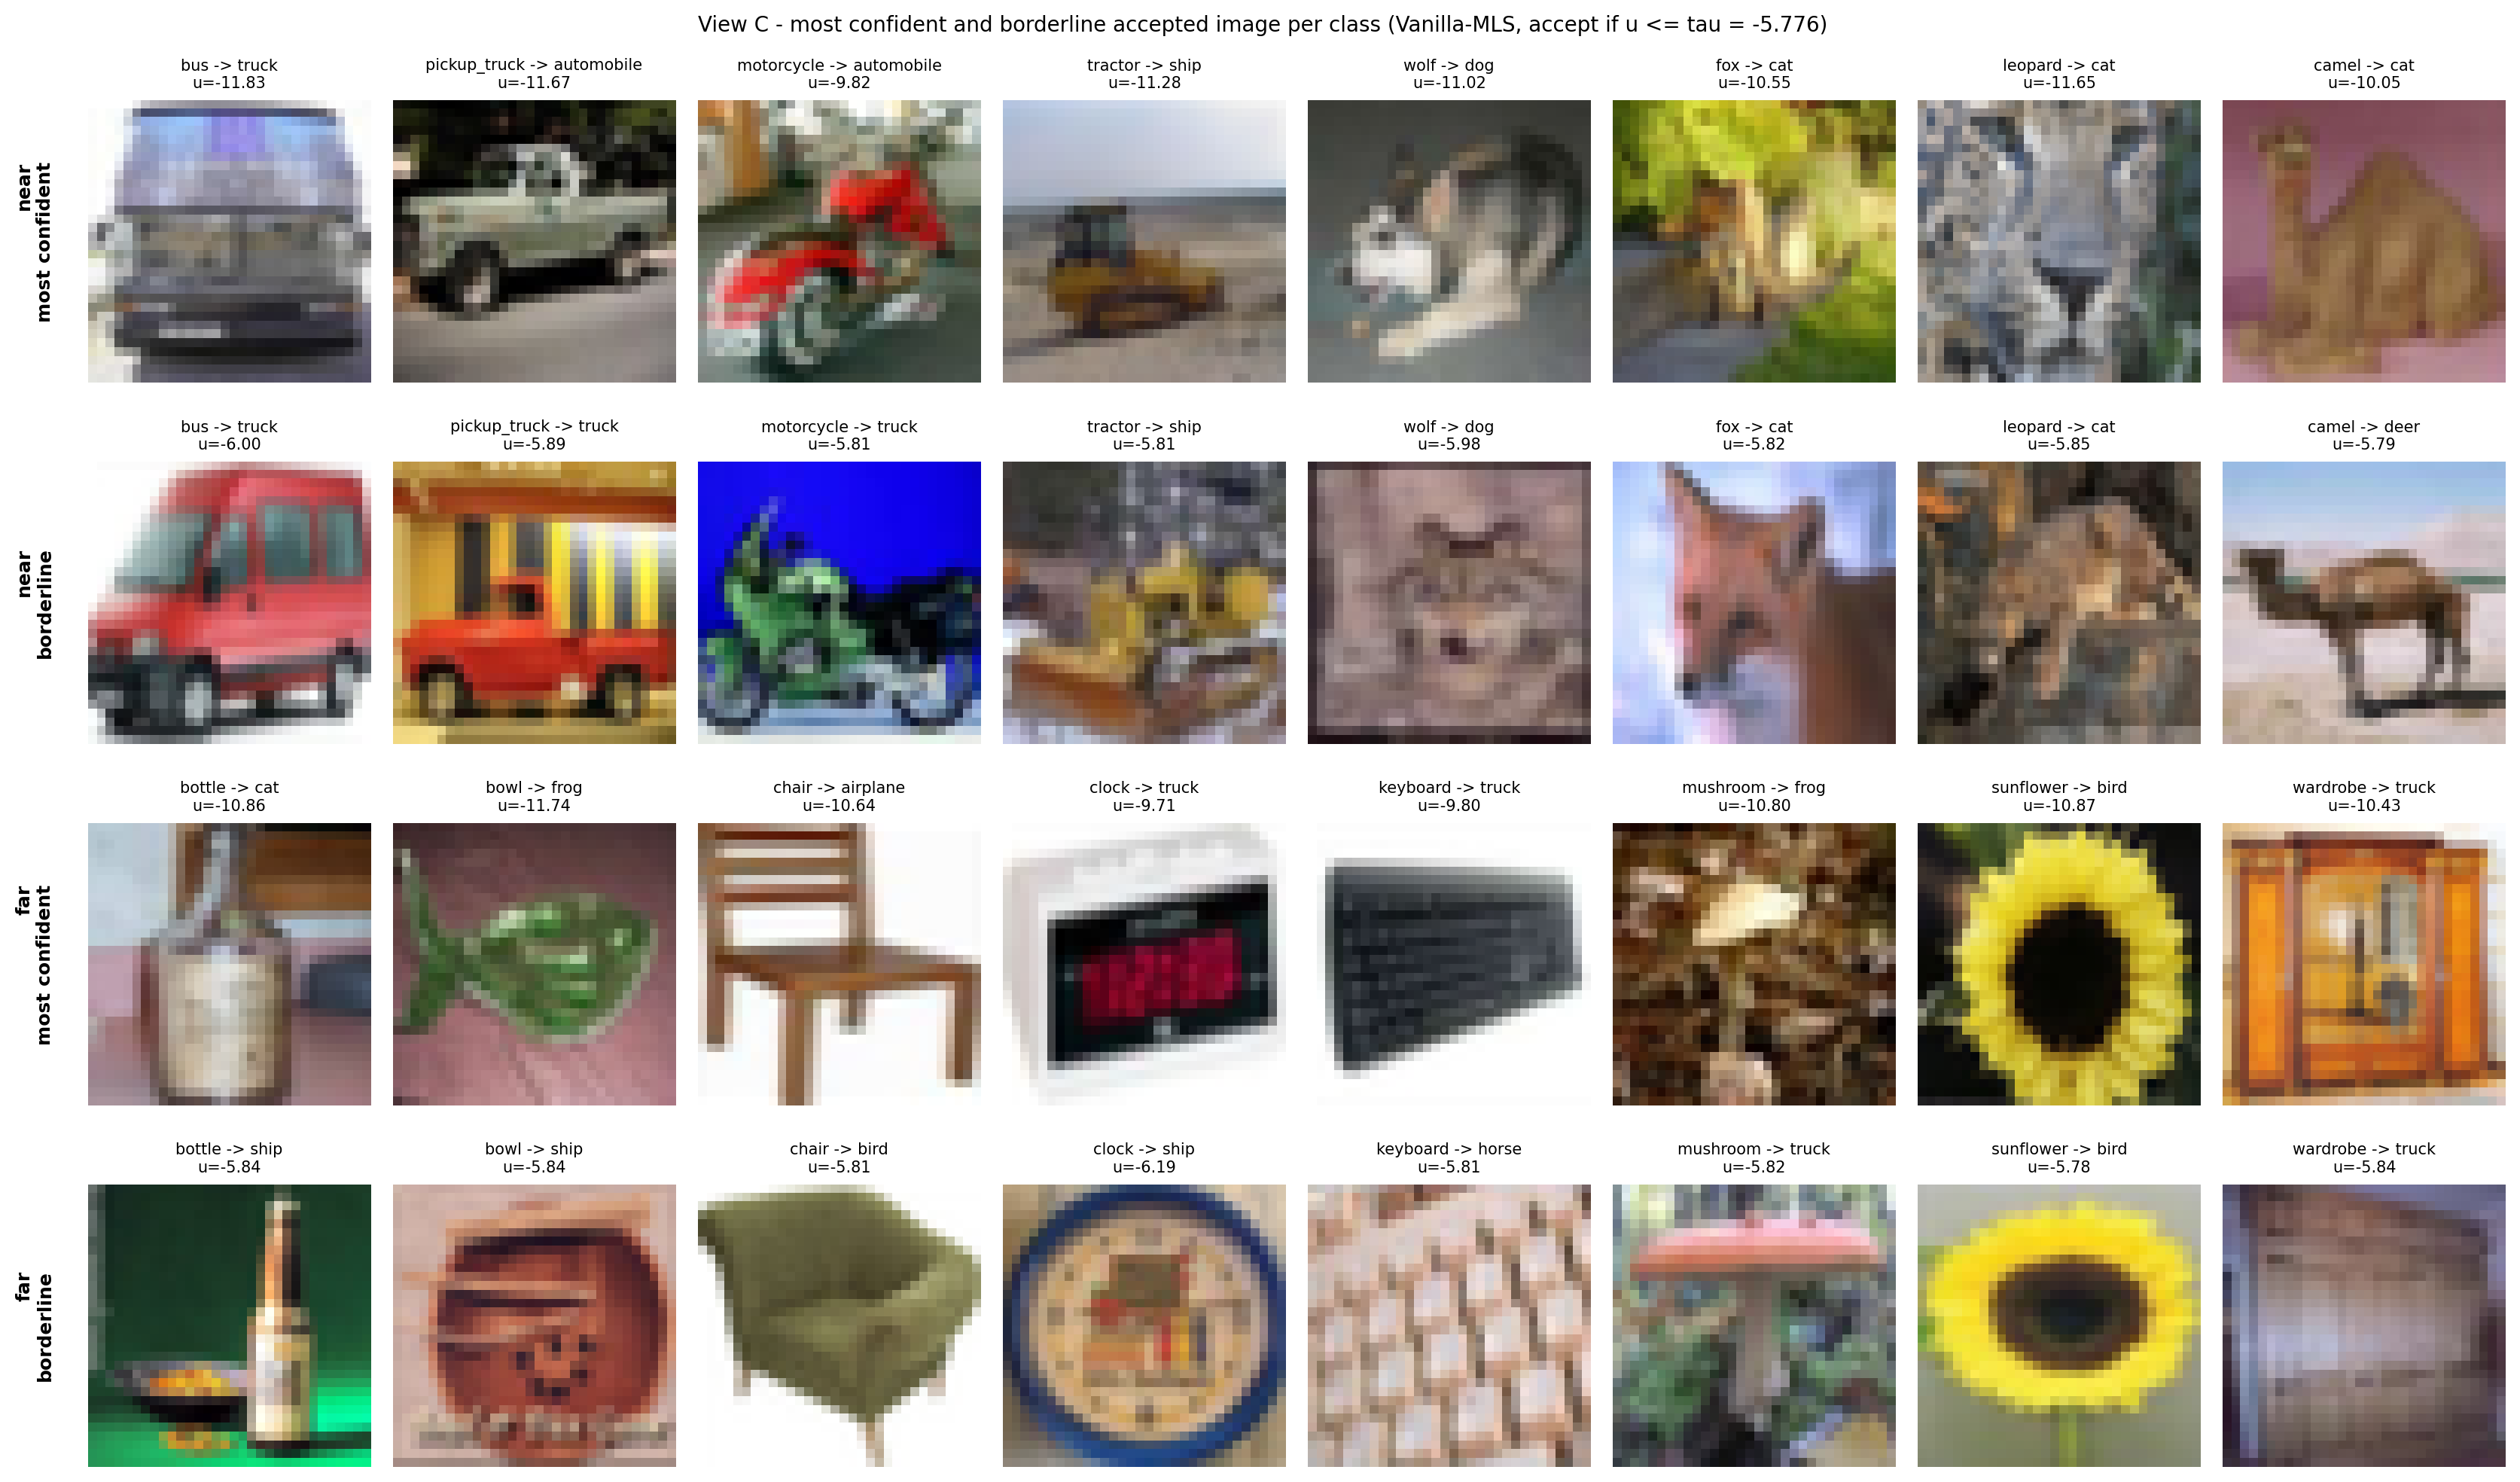

,role,group,fine_class,index,pred,second_choice,u,tau,margin_below_tau,max_logit,max_softmax
0,most confident,near,bus,5201,truck,automobile,-11.834,-5.776,6.058,11.834,1.000
1,borderline,near,bus,3236,truck,automobile,-6.003,-5.776,0.228,6.003,0.658
2,most confident,near,pickup_truck,9081,automobile,truck,-11.672,-5.776,5.896,11.672,1.000
3,borderline,near,pickup_truck,47,truck,automobile,-5.888,-5.776,0.112,5.888,0.500
4,most confident,near,motorcycle,3376,automobile,truck,-9.819,-5.776,4.043,9.819,1.000
5,borderline,near,motorcycle,6022,truck,airplane,-5.813,-5.776,0.037,5.813,0.927
6,most confident,near,tractor,8996,ship,truck,-11.280,-5.776,5.504,11.280,1.000
7,borderline,near,tractor,2101,ship,deer,-5.806,-5.776,0.030,5.806,0.958
8,most confident,near,wolf,720,dog,cat,-11.022,-5.776,5.246,11.022,1.000
9,borderline,near,wolf,6324,dog,cat,-5.983,-5.776,0.208,5.983,0.677


[G1b] saved /kaggle/working/outputs/task4_outputs.zip (51 files, 2.5 MB) and /kaggle/working/outputs/task4_checkpoints.zip (6 checkpoints, 256 MB)
[G1b] saved /kaggle/working/outputs/task4_cache.zip (372 MB of features/logits)


In [17]:
run(f'python -m task4.evaluation.failure_analysis --view confident_borderline --set {COMMON}')
display(Image(f'{FINAL_DIR}/failures/view_confident_borderline/grid.png', width=1100))
display(pd.read_csv(f'{FINAL_DIR}/failures/view_confident_borderline/selected.csv').round(3))
save_outputs('G1b')

### G1c. Supplementary view B - seeded random sample (separate; report it or not, later)
This is 6 accepted images per group, drawn at random with seed 6304. The main selection shows only the extremes;
this shows what a **typical** accepted unknown looks like.

View B was chosen over the other option (A: the 6 most confident images overall, ignoring class). A would mostly
repeat the top of the main selection and could be six images of one class. Output folder:
`failures/view_random_sample/`.

$ python -m task4.evaluation.failure_analysis --view random --set data_root=/tmp/cifar cache_dir=/tmp/task4_cache
your_judgement.csv: 12 new row(s) from view 'random'; 44 rows in total, 0 already judged (your entries are never overwritten)
freeze record verified: 3 checkpoints, 12 code files, 3 Mahalanobis statistics files unchanged since 2026-09-21T07:35:54+00:00
CIFAR-100 unknowns loaded (1600 images). Access #4; freeze 2026-09-21T07:35:54+00:00 <= first access 2026-09-21T08:27:39+00:00

view: random
rule: A random sample of 6 accepted images per group (near, far): the group's accepted images are sorted by (u_MLS, CIFAR-100 index), then numpy default_rng(6304).choice picks 6 without replacement (all of them if fewer); shown in ascending u_MLS order.
Vanilla-MLS threshold tau = -5.7756  (accept if u = -max logit <= tau, i.e. max logit >= 5.7756)
accepted unknowns: near 560/800, far 361/800

selected images:
group   fine_class  index       pred second_choice      u    tau  margin_below

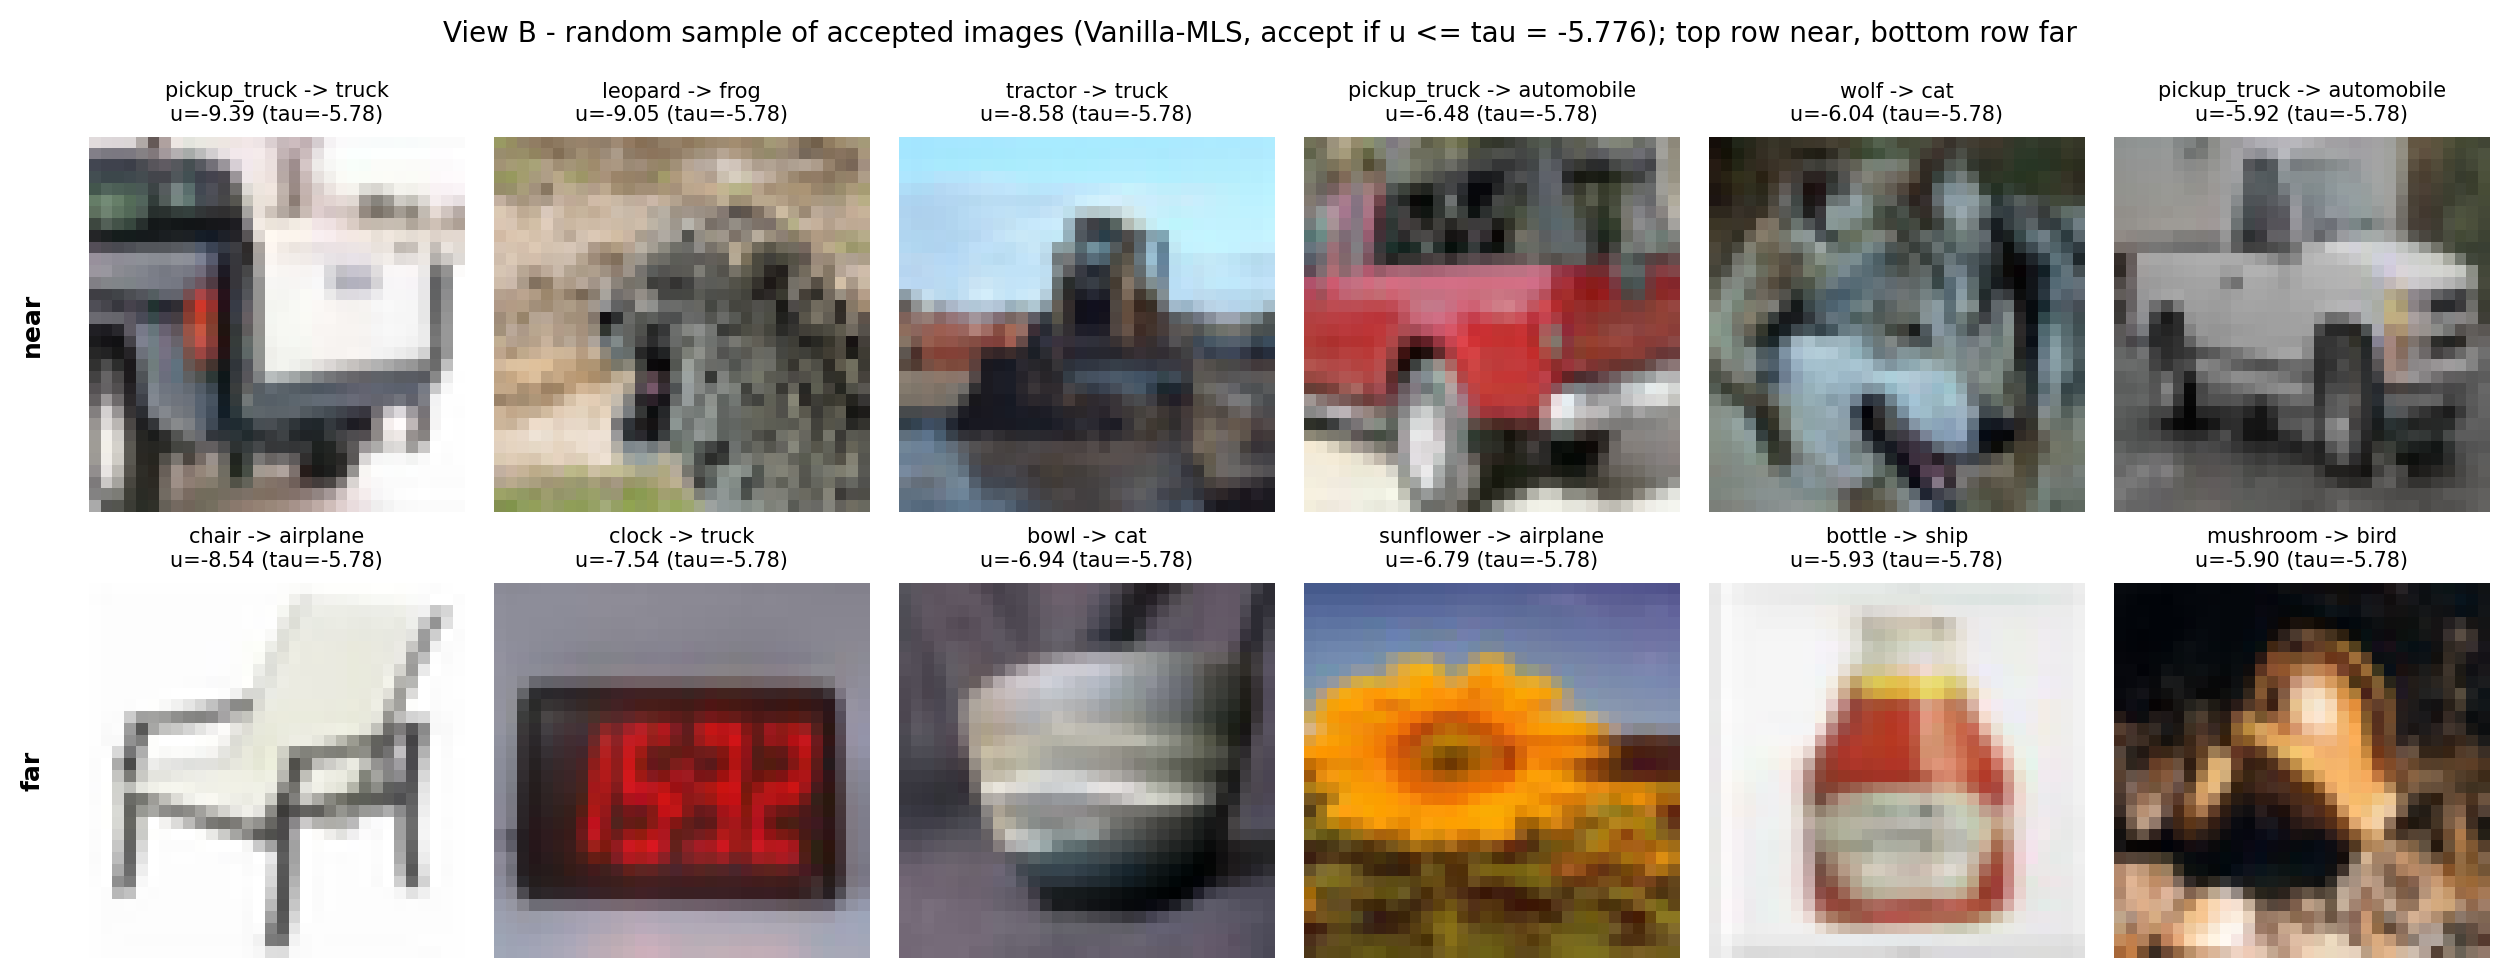

,group,fine_class,index,pred,second_choice,u,tau,margin_below_tau,max_logit,max_softmax
0,near,pickup_truck,9880,truck,automobile,-9.388,-5.776,3.613,9.388,0.999
1,near,leopard,5698,frog,bird,-9.048,-5.776,3.272,9.048,0.999
2,near,tractor,6430,truck,ship,-8.575,-5.776,2.799,8.575,0.991
3,near,pickup_truck,1491,automobile,truck,-6.479,-5.776,0.703,6.479,0.954
4,near,wolf,3927,cat,dog,-6.040,-5.776,0.264,6.040,0.908
5,near,pickup_truck,3537,automobile,truck,-5.918,-5.776,0.143,5.918,0.576
6,far,chair,6245,airplane,horse,-8.542,-5.776,2.766,8.542,0.999
7,far,clock,7933,truck,automobile,-7.542,-5.776,1.767,7.542,0.986
8,far,bowl,6069,cat,automobile,-6.942,-5.776,1.167,6.942,0.986
9,far,sunflower,8866,airplane,bird,-6.795,-5.776,1.019,6.795,0.887


Your judgement sheet: one row per image across all three views (blank until you fill it):


,group,fine_class,index,pred,second_choice,u,tau,in_views,your_call,your_reason
0,near,bus,5201,truck,automobile,-11.834,-5.776,main;confident_borderline,,
1,near,pickup_truck,9081,automobile,truck,-11.672,-5.776,main;confident_borderline,,
2,near,leopard,6055,cat,bird,-11.646,-5.776,main;confident_borderline,,
3,near,tractor,8996,ship,truck,-11.280,-5.776,main;confident_borderline,,
4,near,wolf,720,dog,cat,-11.022,-5.776,main;confident_borderline,,
5,near,fox,4706,cat,deer,-10.549,-5.776,main;confident_borderline,,
6,far,bowl,9561,frog,cat,-11.737,-5.776,main;confident_borderline,,
7,far,sunflower,5260,bird,cat,-10.865,-5.776,main;confident_borderline,,
8,far,bottle,3888,cat,bird,-10.857,-5.776,main;confident_borderline,,
9,far,mushroom,3502,frog,deer,-10.797,-5.776,main;confident_borderline,,


access log: {'frozen_at': '2026-09-21T07:35:54+00:00', 'accesses': [{'time': '2026-09-21T08:27:39+00:00', 'n_images': 1600}, {'time': '2026-09-21T08:29:08+00:00', 'n_images': 1600}, {'time': '2026-09-21T08:29:19+00:00', 'n_images': 1600}, {'time': '2026-09-21T08:29:31+00:00', 'n_images': 1600}]}
[G1c] saved /kaggle/working/outputs/task4_outputs.zip (55 files, 2.7 MB) and /kaggle/working/outputs/task4_checkpoints.zip (6 checkpoints, 256 MB)
[G1c] saved /kaggle/working/outputs/task4_cache.zip (372 MB of features/logits)


In [18]:
run(f'python -m task4.evaluation.failure_analysis --view random --set {COMMON}')
display(Image(f'{FINAL_DIR}/failures/view_random_sample/grid.png', width=1100))
display(pd.read_csv(f'{FINAL_DIR}/failures/view_random_sample/selected.csv').round(3))
print('Your judgement sheet: one row per image across all three views (blank until you fill it):')
display(pd.read_csv(f'{FINAL_DIR}/failures/your_judgement.csv', keep_default_na=False).round(3))
print('access log:', json.load(open(f'{FROZEN_DIR}/unknown_access_log.json')))
TIMES['G failures'] = (time.time() - t0) / 60
save_outputs('G1c')

### G2. Suggested plausibility map - SEPARATE, for reference after your own judgement
This applies **Claude's suggested map** (`task4/configs/plausibility_map.yaml`) to the main selection and to views
C and B:
- vehicles -> automobile/truck
- wolf -> dog
- fox -> dog/cat
- leopard -> cat
- camel -> horse/deer
- far classes -> none

It is not pre-registered, not part of the freeze record, and changes no metric. Its output goes to its own
folder, `failures/suggested_map/`, so it never mixes with the neutral results above.

Suggested order:
1. Look at the images in G1, G1b and G1c.
2. Fill in `your_judgement.csv` yourself.
3. Edit the YAML if you disagree with the map.
4. Re-run locally: `python -m task4.evaluation.apply_plausibility_map`. It takes seconds and needs no GPU and no
   CIFAR-100. It then lists, row by row, where your calls and the map agree.

In [19]:
run(f'python -m task4.evaluation.apply_plausibility_map --set {COMMON}')
save_outputs('G2')

$ python -m task4.evaluation.apply_plausibility_map --set data_root=/tmp/cifar cache_dir=/tmp/task4_cache
SUGGESTED plausibility map: task4/configs/plausibility_map.yaml  (suggested by Claude on 2026-09-20; not yet reviewed)
  Not pre-registered and not in the freeze record; it only labels the failures and changes no metric.

the map:
  near: bus -> automobile/truck; pickup_truck -> automobile/truck; motorcycle -> automobile/truck; tractor -> automobile/truck; wolf -> dog; fox -> dog/cat; leopard -> cat; camel -> horse/deer
  far: bottle -> (none); bowl -> (none); chair -> (none); clock -> (none); keyboard -> (none); mushroom -> (none); sunflower -> (none); wardrobe -> (none)

main selection with the map's label:
group   fine_class       pred       u    tau plausible_targets  map_label
 near          bus      truck -11.834 -5.776  automobile/truck  plausible
 near pickup_truck automobile -11.672 -5.776  automobile/truck  plausible
 near      leopard        cat -11.646 -5.776           

## Part I - POST-HOC: PROSER and BatchNorm (separate from the pre-registered results)

**Why.** In run 1, PROSER's CIFAR-10 **validation** accuracy fell from 94.6% (epoch 1) to 85-93%, while training
accuracy stayed at 99.9%. The dummy came to beat every known class on up to 100% of validation images, so the
checkpoint rule kept epoch 1. All of this evidence is CIFAR-10 only; Part D above shows the same curves for this
run.

**Suspected cause.** The mixed features pass through layer3/layer4 in their own forward call. BatchNorm's running
statistics, which are used only at evaluation time, then partly describe mixed features instead of real images.

**What this Part adds.** Everything here is labelled post-hoc and kept out of Tables 1 and 2.
- **I1 - diagnosis (CIFAR-10 only).** Re-estimate the running statistics from real training images and re-measure
  validation accuracy and dummy-wins. It also shows which layers' statistics were off.
- **I2 - variant (CIFAR-10 only).** PROSER trained exactly as in Part D (same losses, seed and data order, so the
  same weights), except that the BatchNorm statistics are re-estimated from real training images after every
  epoch, before validation and checkpoint selection.
- **I3 - variant evaluation.** A separate freeze record for the variant is written before its first CIFAR-100
  access. It is then compared with Vanilla-MLS and the original PROSER on the same images.

This variant was decided after run 1's CIFAR-100 results had been seen, so report it as post-hoc. Ideally, clear it
with the TA, as with the Task 3 estimator question.

In [20]:
# I1. BatchNorm diagnosis - CIFAR-10 training + validation images only.
t0 = time.time()
run(f'python -m task4.posthoc.bn_diagnosis --set {COMMON}')
display(pd.read_csv('task4/results/posthoc/bn_diagnosis.csv').round(3))
TIMES['I1 diagnosis'] = (time.time() - t0) / 60
save_outputs('I1')

$ python -m task4.posthoc.bn_diagnosis --set data_root=/tmp/cifar cache_dir=/tmp/task4_cache
Validation accuracy (10 known logits) and % of validation images where the strongest dummy beats every known class,
with the running statistics as saved vs re-estimated from real training images:

     checkpoint  epoch  val_acc_as_saved  val_acc_bn_reestimated  dummy_wins_as_saved  dummy_wins_bn_reestimated
vanilla/best.pt     96             94.92                   94.88                  NaN                        NaN
 proser/best.pt      1             94.64                   94.76                 5.68                       5.58
 proser/last.pt     50             89.46                   95.02               100.00                       2.32

How far the saved running means are from the re-estimated ones (average |shift| in standard deviations),
by network stage - mixed features only pass through layer3 and layer4:

     checkpoint  mean_shift_stem  mean_shift_layer1  mean_shift_layer2  mean_shi

,checkpoint,role,epoch,val_acc_as_saved,val_acc_bn_reestimated,dummy_wins_as_saved,dummy_wins_bn_reestimated,recal_images,mean_shift_stem,mean_shift_layer1,mean_shift_layer2,mean_shift_layer3,mean_shift_layer4
0,vanilla/best.pt,control: never saw mixed features,96,94.92,94.88,NaN,NaN,25600,0.003,0.001,0.001,0.002,0.003
1,proser/best.pt,selected PROSER checkpoint,1,94.64,94.76,5.68,5.58,25600,0.017,0.002,0.002,0.004,0.006
2,proser/last.pt,PROSER after all 50 epochs,50,89.46,95.02,100.00,2.32,25600,0.003,0.002,0.002,0.011,0.062


[I1] saved /kaggle/working/outputs/task4_outputs.zip (65 files, 2.7 MB) and /kaggle/working/outputs/task4_checkpoints.zip (6 checkpoints, 256 MB)
[I1] saved /kaggle/working/outputs/task4_cache.zip (372 MB of features/logits)


$ python -m task4.train --config task4/configs/proser_bncal.yaml --set data_root=/tmp/cifar cache_dir=/tmp/task4_cache
PROSER initialised from /kaggle/working/PA1/task4/results/runs/vanilla/best.pt (Vanilla epoch 96, val acc 94.92%) + 5 random dummy classifiers
=== proser_bncal ===
  method        : PROSER: 5 dummies (max = placeholder logit); first half CE + 1.0 x masked-CE->dummy; second half manifold mixup after layer2, lambda~Beta(2.0,2.0), different classes only, CE->dummy weighted 0.1
  device        : Tesla T4 | AMP True | channels_last True | cuDNN deterministic True
  data          : train 45000 images (classes [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), val 5000 images
  optimisation  : SGD lr 0.001 momentum 0.9 wd 0.0005, cosine over 50 epochs, batch 128, 352 steps/epoch, seed 6304
  parameters    : 11.18 M
  checkpoint    : highest CIFAR-10 validation accuracy -> /kaggle/working/PA1/task4/results/posthoc/runs/proser_bncal/best.pt

ep   1/50 | lr 0.00100 | loss 0.6384 | train  99.90% |

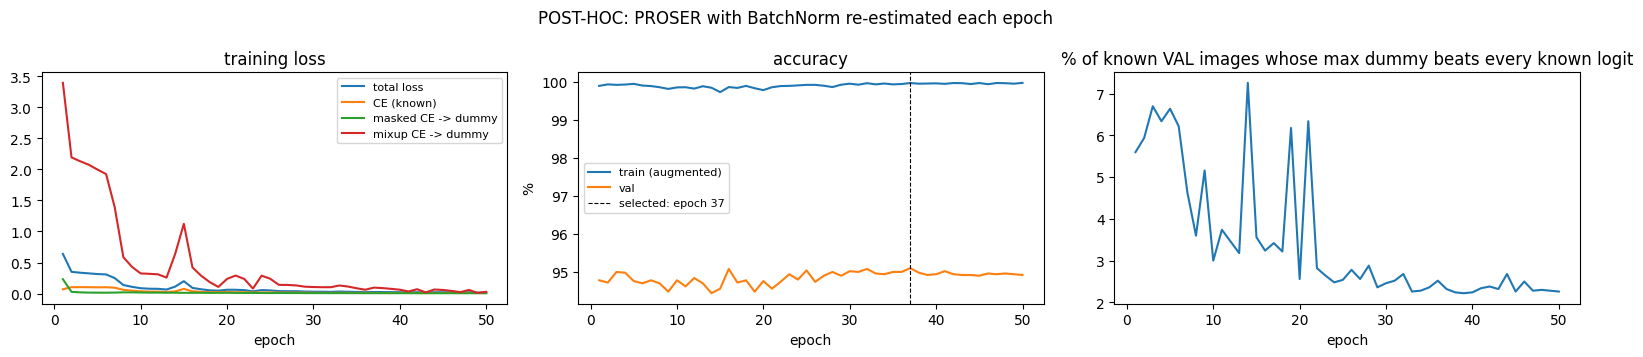

proser_bncal: best val acc 95.10% at epoch 37 / 50, last epoch 94.92%, 25.5 min on Tesla T4
original PROSER selected epoch 1 (94.64%); variant selected epoch 37 (95.10%), dummy-wins there 2.32%
[I2] saved /kaggle/working/outputs/task4_outputs.zip (68 files, 2.7 MB) and /kaggle/working/outputs/task4_checkpoints.zip (8 checkpoints, 342 MB)
[I2] saved /kaggle/working/outputs/task4_cache.zip (372 MB of features/logits)


In [21]:
# I2. The variant: PROSER + BatchNorm statistics re-estimated from real training images after every epoch.
t0 = time.time()
run(f'python -m task4.train --config task4/configs/proser_bncal.yaml --set {COMMON}')
h_b, s_b = show_history('proser_bncal', 'POST-HOC: PROSER with BatchNorm re-estimated each epoch',
                        runs_dir='task4/results/posthoc/runs')
print(f"original PROSER selected epoch {s_p['best_epoch']} ({s_p['best_val_acc']:.2f}%); variant selected epoch "
      f"{s_b['best_epoch']} ({s_b['best_val_acc']:.2f}%), dummy-wins there "
      f"{h_b.loc[h_b.epoch == s_b['best_epoch'], 'val_dummy_wins'].item():.2f}%")
TIMES['I2 variant'] = (time.time() - t0) / 60
save_outputs('I2')

$ python -m task4.posthoc.evaluate_variant --set data_root=/tmp/cifar cache_dir=/tmp/task4_cache
freeze record verified: 3 checkpoints, 12 code files, 3 Mahalanobis statistics files unchanged since 2026-09-21T07:35:54+00:00
variant proser_bncal: /kaggle/working/PA1/task4/results/posthoc/runs/proser_bncal/best.pt (epoch 37, val acc 95.10%, sha256 0cf0f57b393750f5...)
POST-HOC FROZEN at 2026-09-21T08:56:38+00:00 -> /kaggle/working/PA1/task4/results/posthoc/frozen_posthoc.json
  thresholds: MLS tau = -5.88994, PROSER-detect tau = -8.8432e-05 (val acceptance 95.00% / 95.00%)
freeze record verified: 3 checkpoints, 12 code files, 3 Mahalanobis statistics files unchanged since 2026-09-21T07:35:54+00:00
CIFAR-100 unknowns loaded (1600 images). Access #5; freeze 2026-09-21T07:35:54+00:00 <= first access 2026-09-21T08:27:39+00:00
bootstrap: 2000 stratified resamples (seed 6304) ...

POST-HOC TABLE - PROSER with BatchNorm statistics re-estimated from real training images (numbers in %)
       mod

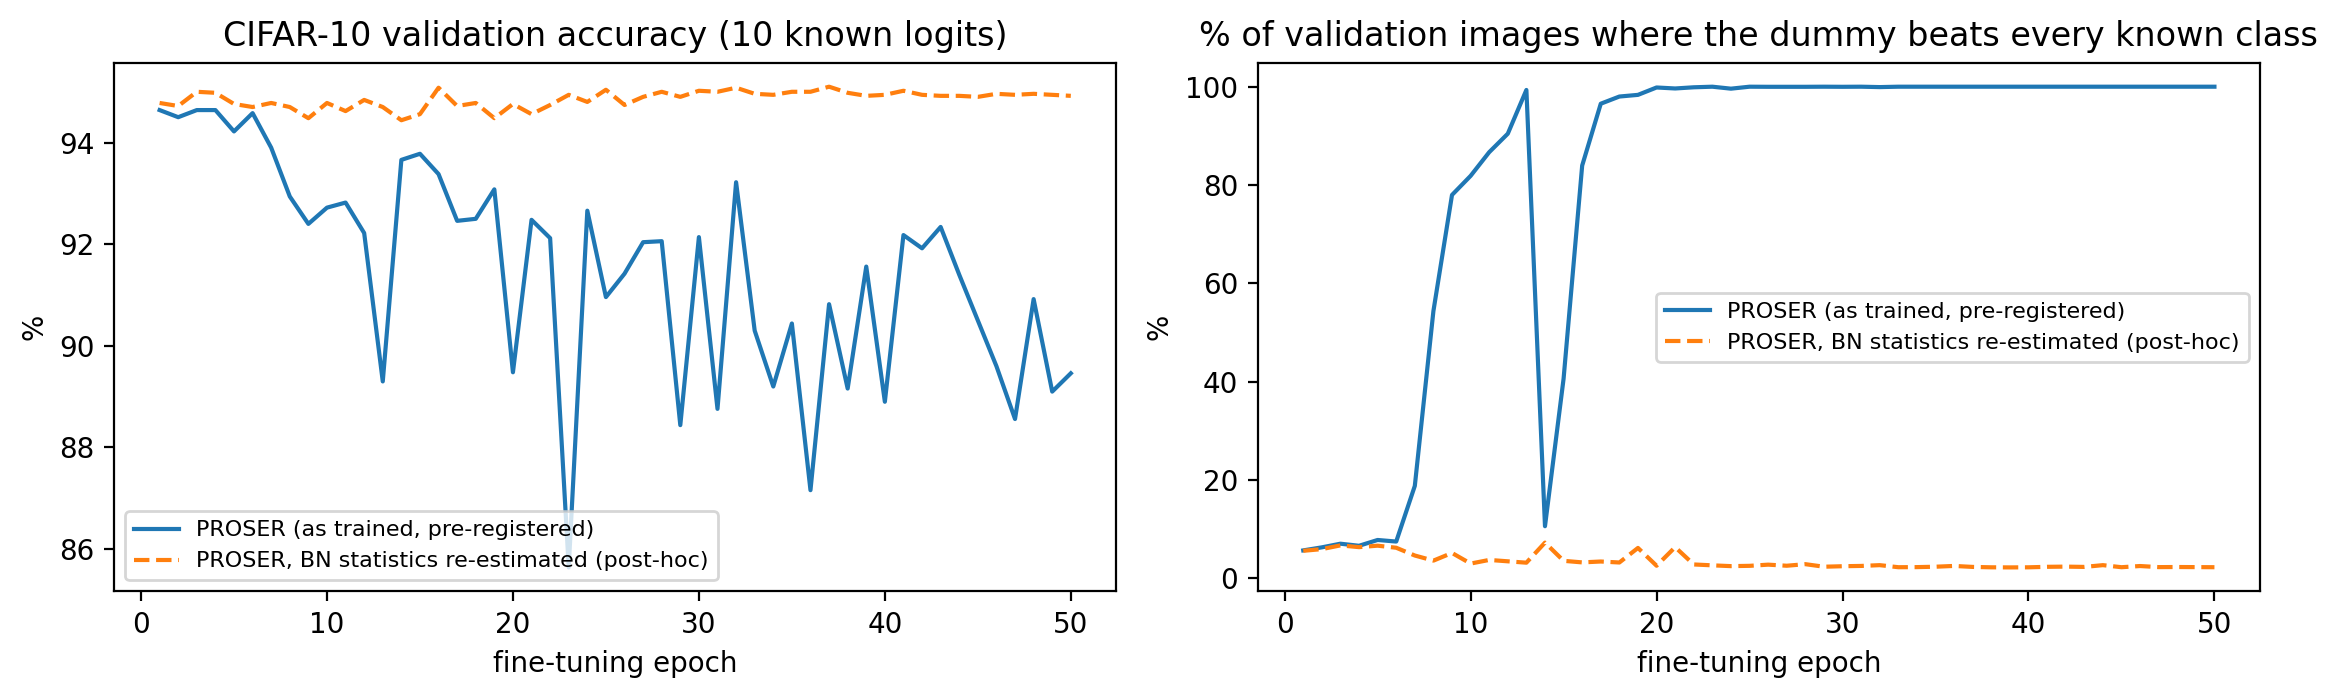

,model,score,status,CSA,AUROC_near,AUROC_far,AUROC_all,test_accept,reject_near,reject_far,FPR95_near,FPR95_far,FPR95_all
0,vanilla,MLS,pre-registered,94.40,79.11,90.14,84.63,95.32,30.00,54.88,70.00,45.12,57.56
1,proser,MLS,pre-registered,94.26,79.37,88.90,84.14,95.34,25.25,47.88,74.75,52.12,63.44
2,proser,PROSER-detect,pre-registered,94.26,78.62,87.74,83.18,95.33,24.62,43.75,75.38,56.25,65.81
3,proser_bncal,MLS,POST-HOC,94.57,77.95,91.60,84.77,95.48,27.50,54.50,72.50,45.50,59.00
4,proser_bncal,PROSER-detect,POST-HOC,94.57,78.48,91.25,84.87,95.39,25.50,51.00,74.50,49.00,61.75


,table,group,A,B,AUROC_A_minus_B,CI_low,CI_high,p_boot,p_holm,significant_0.05
0,posthoc,near,proser_bncal-MLS,vanilla-MLS,-1.157,-2.250,0.008,0.053,0.159,False
1,posthoc,near,proser_bncal-PROSER-detect,vanilla-MLS,-0.624,-1.718,0.505,0.302,0.604,False
2,posthoc,near,proser_bncal-MLS,proser-MLS,-1.418,-2.686,-0.116,0.027,0.108,False
3,posthoc,near,proser_bncal-PROSER-detect,proser-PROSER-detect,-0.133,-1.656,1.456,0.904,0.904,False
4,posthoc,far,proser_bncal-MLS,vanilla-MLS,1.455,0.682,2.210,0.001,0.004,True
5,posthoc,far,proser_bncal-PROSER-detect,vanilla-MLS,1.106,0.364,1.892,0.004,0.004,True
6,posthoc,far,proser_bncal-MLS,proser-MLS,2.694,1.840,3.580,0.001,0.004,True
7,posthoc,far,proser_bncal-PROSER-detect,proser-PROSER-detect,3.512,2.520,4.556,0.001,0.004,True
8,posthoc,all,proser_bncal-MLS,vanilla-MLS,0.149,-0.520,0.853,0.654,0.984,False
9,posthoc,all,proser_bncal-PROSER-detect,vanilla-MLS,0.241,-0.421,0.949,0.492,0.984,False


,A,B,CSA_A,CSA_B,diff,only_A_correct,only_B_correct,p_exact,p_holm,significant_0.05
0,proser_bncal,vanilla,94.57,94.40,0.17,118,101,0.2796,0.2796,False
1,proser_bncal,proser,94.57,94.26,0.31,149,118,0.0662,0.1323,False


[I3] saved /kaggle/working/outputs/task4_outputs.zip (76 files, 2.9 MB) and /kaggle/working/outputs/task4_checkpoints.zip (8 checkpoints, 342 MB)
[I3] saved /kaggle/working/outputs/task4_cache.zip (406 MB of features/logits)


In [22]:
# I3. Post-hoc freeze of the variant (CIFAR-10 only), then its CIFAR-100 evaluation next to the pre-registered rows.
t0 = time.time()
run(f'python -m task4.posthoc.evaluate_variant --set {COMMON}')
display(Image('task4/results/posthoc/fig_proser_bn.png', width=1000))
tp = pd.read_csv('task4/results/posthoc/table_posthoc_proser_bncal.csv')
display(tp[['model', 'score', 'status'] + [c for c in main_cols if c not in ('model', 'score')]].round(2))
display(pd.read_csv('task4/results/posthoc/auroc_comparisons_posthoc.csv').round(3))
display(pd.read_csv('task4/results/posthoc/csa_mcnemar_posthoc.csv').round(4))
TIMES['I3 variant eval'] = (time.time() - t0) / 60
save_outputs('I3')

## Part H - package

- `outputs/task4_outputs.zip`: extract it **at the repository root**. It fills `task4/results/` and
  `task4/data/splits/`. Commit all of it: configs used, histories, the freeze record, per-image scores, tables,
  figures and failures. It has no checkpoints.
- `outputs/task4_checkpoints.zip`: the three `best.pt` files (about 45 MB each). Keep a copy but do not commit it;
  `.gitignore` excludes `*.pt`.
- `outputs/task4_cache.zip`: the saved features and logits (about 0.4 GB). Keep it next to the checkpoints if you
  may re-run `evaluate_osr` or `failure_analysis` later (extract it into `task4/cache/`). Do not commit it.
- Commit this notebook, once it has run, as `notebooks/task4_kaggle_executed.ipynb`.

In [23]:
TIMES['total'] = (time.time() - T_START) / 60
json.dump({'minutes': TIMES, 'env': ENV}, open('task4/results/run_times.json', 'w'), indent=2)
save_outputs('H')
for k, v in TIMES.items():
    print(f'  {k:18s} {v:6.1f} min')
import zipfile
names = zipfile.ZipFile(f'{OUT}/task4_outputs.zip').namelist()
print(f'\ntask4_outputs.zip holds {len(names)} files, e.g.:')
for n in sorted(names)[:12] + ['...'] + sorted(names)[-8:]:
    print('  ', n)
assert not any(n.endswith('.pt') for n in names)
print('\nDONE. Download both zips from the Output tab of this saved version.')

[H] saved /kaggle/working/outputs/task4_outputs.zip (77 files, 2.9 MB) and /kaggle/working/outputs/task4_checkpoints.zip (8 checkpoints, 342 MB)
[H] saved /kaggle/working/outputs/task4_cache.zip (406 MB of features/logits)
  B vanilla            25.8 min
  C gcsc               29.6 min
  D proser             14.6 min
  E extract+freeze      1.7 min
  F evaluate           53.0 min
  G failures            0.5 min
  I1 diagnosis          1.1 min
  I2 variant           25.6 min
  I3 variant eval       1.1 min
  total               154.7 min

task4_outputs.zip holds 77 files, e.g.:
   task4/data/splits/cifar10_split_seed6304.json
   task4/results/environment.json
   task4/results/final/absorption_counts.csv
   task4/results/final/acceptance_by_class.csv
   task4/results/final/all_models_all_scores.csv
   task4/results/final/auroc_comparisons.csv
   task4/results/final/csa_mcnemar.csv
   task4/results/final/decision_overlap_unknowns.csv
   task4/results/final/failures/acceptance_by_class_van